# ⚖️ Law Curves · 🧀 Heat/Phase · 🗄️ SQL Advanced · 📡 Beamforming · 🏗️ Civil Eng · 🌀 Complex · ⚛️ QM

> Two weeks of frustration compressed into one notebook.
> Every section is a complete engineering treatment — not surface level.

| § | Topic |
|---|---|
| §1 | Law curves — Laffer, Phillips, supply/demand, Okun's law |
| §2 | Heat equation + phase transition — cheese melting (Stefan problem) |
| §3 | SQL advanced — window functions, CTEs, recursive queries |
| §4 | Directed energy beamforming — phased array, beam steering, MIMO |
| §5 | Civil engineering — beam bending, shear/moment diagrams, Euler buckling |
| §6 | Complex analysis — Laurent series, residues, conformal maps |
| §7 | Quantum mechanics — Schrödinger, particle-in-box, harmonic oscillator, H atom |

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import sqlite3, warnings
from scipy import linalg, integrate as sci_int, special
warnings.filterwarnings('ignore')
np.random.seed(2026)
sp.init_printing(use_latex='mathjax')
from IPython.display import display, Math
print('Law - Heat - SQL - Beam - Civil - Complex - QM  ready')

Law - Heat - SQL - Beam - Civil - Complex - QM  ready


---
## §1 ⚖️ Law Curves — Laffer · Phillips · Supply/Demand · Okun

**Laffer curve:** revenue $R(\tau) = \tau \cdot B(\tau)$ where tax base $B(\tau)$ shrinks
as rate rises. Revenue maximized at $\tau^* = 1/(1+\epsilon)$ where $\epsilon$ is
elasticity of taxable income.

**Phillips curve (expectations-augmented):**
$$\pi_t = \pi_t^e + \alpha(u^* - u_t) + \varepsilon_t$$
Stagflation (1970s) broke the original static Phillips curve — expectations matter.

**Okun's law:** $\Delta u \approx -0.5 \cdot (\Delta GDP - \Delta GDP^*)$

§1.1 Laffer curve revenue-maximizing tax rates:
  Inelastic           : tau* = 66.7%
  Moderate            : tau* = 40.0%
  Elastic capital     : tau* = 25.0%

§1.2 Supply/demand equilibrium:
  Equilibrium: P*=22.00  Q*=76.00
  Price floor 30.0: surplus  = 40.0 units
  Price ceil  15.0: shortage = 35.0 units

§1.3 Phillips curve (alpha=0.5, u*=5%):
  pi_e=0%: pi(u=4%) = 0.5%
  pi_e=2%: pi(u=4%) = 2.5%
  pi_e=5%: pi(u=4%) = 5.5%
  pi_e=8%: pi(u=4%) = 8.5%

§1.4 Okun's law fit: du = -0.514*dGDP + 1.059  R=-0.969


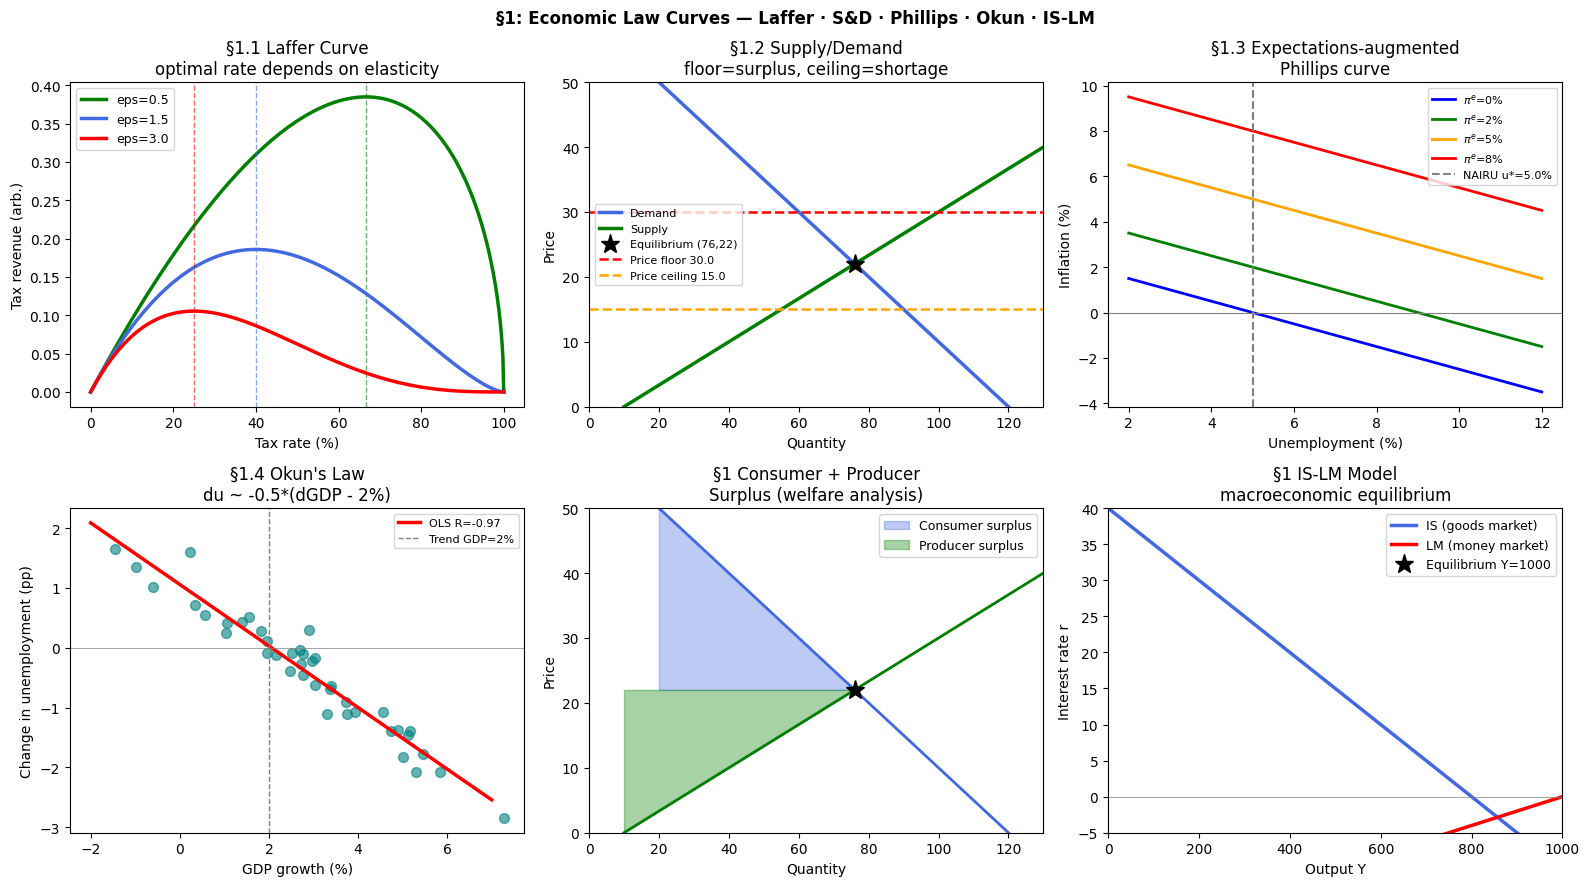

In [2]:
# §1 Law curves

x, tau, u, pi_e = sp.symbols('x tau u pi_e', real=True)

# §1.1 Laffer curve: R = tau * (1 - tau)^epsilon / (1+epsilon)
epsilon_val = 1.5   # elasticity of taxable income
tau_arr = np.linspace(0, 1, 500)

def laffer(tau_a, eps):
    base    = (1 - tau_a)**eps   # tax base shrinks
    revenue = tau_a * base
    return revenue

rev_lo  = laffer(tau_arr, 0.5)   # inelastic base
rev_mid = laffer(tau_arr, 1.5)   # moderate elasticity
rev_hi  = laffer(tau_arr, 3.0)   # elastic (capital flight)

# Revenue-maximizing rates
tau_star = lambda eps: 1/(1+eps)
print('§1.1 Laffer curve revenue-maximizing tax rates:')
for eps,name in [(0.5,'Inelastic'),(1.5,'Moderate'),(3.0,'Elastic capital')]:
    ts = tau_star(eps)
    print(f'  {name:20s}: tau* = {ts:.1%}')

# §1.2 Supply/demand with price floor/ceiling
print('\n§1.2 Supply/demand equilibrium:')
# Demand: Q_d = a - b*P,  Supply: Q_s = c + d*P
a_d,b_d, c_s,d_s = 120, 2.0, 10, 3.0
P_eq = (a_d - c_s)/(b_d + d_s)
Q_eq = a_d - b_d*P_eq
print(f'  Equilibrium: P*={P_eq:.2f}  Q*={Q_eq:.2f}')

P_range  = np.linspace(0, 50, 300)
Q_demand = np.maximum(0, a_d - b_d*P_range)
Q_supply = np.maximum(0, c_s + d_s*P_range)

P_floor  = 30.0  # minimum wage analog
P_ceil   = 15.0  # rent control analog
surplus  = (c_s+d_s*P_floor) - (a_d-b_d*P_floor)
shortage = (a_d-b_d*P_ceil) - (c_s+d_s*P_ceil)
print(f'  Price floor {P_floor}: surplus  = {surplus:.1f} units')
print(f'  Price ceil  {P_ceil}: shortage = {shortage:.1f} units')

# §1.3 Phillips curve
u_range  = np.linspace(2, 12, 200)
u_star   = 5.0   # natural unemployment
alpha_ph = 0.5

# Short-run curves at different inflation expectations
pi_expect_vals = [0, 2, 5, 8]
print('\n§1.3 Phillips curve (alpha=0.5, u*=5%):')
for pie in pi_expect_vals:
    pi_at_u4 = pie + alpha_ph*(u_star - 4.0)
    print(f'  pi_e={pie}%: pi(u=4%) = {pi_at_u4:.1f}%')

# §1.4 Okun's law scatter
np.random.seed(10)
gdp_growth  = np.random.normal(2.5, 2.0, 40)
du_okun     = -0.5*(gdp_growth - 2.0) + np.random.normal(0, 0.3, 40)
slope_ok, intercept_ok, r_ok, *_ = __import__('scipy').stats.linregress(gdp_growth, du_okun)
print(f'\n§1.4 Okun\'s law fit: du = {slope_ok:.3f}*dGDP + {intercept_ok:.3f}  R={r_ok:.3f}')

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(16,9))

# Laffer
ax1 = axes[0][0]
for rev,eps,col,name in [(rev_lo,0.5,'green','eps=0.5'),(rev_mid,1.5,'royalblue','eps=1.5'),(rev_hi,3.0,'red','eps=3.0')]:
    ax1.plot(tau_arr*100, rev, lw=2.5, color=col, label=name)
    ts = tau_star(eps)*100
    ax1.axvline(ts, color=col, lw=1, ls='--', alpha=0.6)
ax1.set_xlabel('Tax rate (%)'); ax1.set_ylabel('Tax revenue (arb.)')
ax1.set_title('§1.1 Laffer Curve\noptimal rate depends on elasticity')
ax1.legend(fontsize=9)

# Supply/demand
ax2 = axes[0][1]
ax2.plot(Q_demand, P_range, 'royalblue', lw=2.5, label='Demand')
ax2.plot(Q_supply, P_range, 'green',     lw=2.5, label='Supply')
ax2.plot(Q_eq, P_eq, 'k*', ms=14, label=f'Equilibrium ({Q_eq:.0f},{P_eq:.0f})')
ax2.axhline(P_floor, color='red',   ls='--', lw=1.8, label=f'Price floor {P_floor}')
ax2.axhline(P_ceil,  color='orange',ls='--', lw=1.8, label=f'Price ceiling {P_ceil}')
ax2.set_xlabel('Quantity'); ax2.set_ylabel('Price')
ax2.set_xlim(0,130); ax2.set_ylim(0,50)
ax2.set_title('§1.2 Supply/Demand\nfloor=surplus, ceiling=shortage')
ax2.legend(fontsize=8)

# Phillips curves
ax3 = axes[0][2]
for pie, col in zip(pi_expect_vals, ['blue','green','orange','red']):
    pi_sr = pie + alpha_ph*(u_star - u_range)
    ax3.plot(u_range, pi_sr, lw=2, color=col, label=f'$\pi^e$={pie}%')
ax3.axvline(u_star, color='gray', lw=1.5, ls='--', label=f'NAIRU u*={u_star}%')
ax3.axhline(0, color='gray', lw=0.8)
ax3.set_xlabel('Unemployment (%)'); ax3.set_ylabel('Inflation (%)')
ax3.set_title('§1.3 Expectations-augmented\nPhillips curve')
ax3.legend(fontsize=8)

# Okun scatter
ax4 = axes[1][0]
ax4.scatter(gdp_growth, du_okun, alpha=0.6, s=50, color='teal')
x_ok = np.linspace(-2, 7, 100)
ax4.plot(x_ok, slope_ok*x_ok+intercept_ok, 'r-', lw=2.5, label=f'OLS R={r_ok:.2f}')
ax4.axhline(0, color='gray', lw=0.5); ax4.axvline(2.0, color='gray', ls='--', lw=1, label='Trend GDP=2%')
ax4.set_xlabel('GDP growth (%)'); ax4.set_ylabel('Change in unemployment (pp)')
ax4.set_title("§1.4 Okun's Law\ndu ~ -0.5*(dGDP - 2%)")
ax4.legend(fontsize=8)

# Consumer/producer surplus
ax5 = axes[1][1]
ax5.fill_between(Q_demand, P_range, P_eq, where=(P_range>=P_eq)&(Q_demand>=0),
                  alpha=0.35, color='royalblue', label='Consumer surplus')
ax5.fill_between(Q_supply, P_range, P_eq, where=(P_range<=P_eq)&(Q_supply<=Q_eq),
                  alpha=0.35, color='green', label='Producer surplus')
ax5.plot(Q_demand, P_range, 'royalblue', lw=2)
ax5.plot(Q_supply, P_range, 'green', lw=2)
ax5.plot(Q_eq, P_eq, 'k*', ms=14)
ax5.set_xlim(0,130); ax5.set_ylim(0,50)
ax5.set_xlabel('Quantity'); ax5.set_ylabel('Price')
ax5.set_title('§1 Consumer + Producer\nSurplus (welfare analysis)')
ax5.legend(fontsize=9)

# IS-LM model (bonus)
Y_range = np.linspace(0, 1000, 300)
# IS: r = (a - Y)/b  (investment-savings)
r_IS = (800 - Y_range)/20
# LM: r = (M_demand - Y*k)/h  (liquidity-money)
r_LM = (Y_range*0.2 - 200)/10
Y_eq_islm = np.interp(0, r_IS - r_LM, Y_range)
r_eq_islm = (800-Y_eq_islm)/20
ax6 = axes[1][2]
ax6.plot(Y_range, r_IS, 'royalblue', lw=2.5, label='IS (goods market)')
ax6.plot(Y_range, r_LM, 'red',       lw=2.5, label='LM (money market)')
ax6.plot(Y_eq_islm, r_eq_islm, 'k*', ms=14, label=f'Equilibrium Y={Y_eq_islm:.0f}')
ax6.axhline(0,color='gray',lw=0.5)
ax6.set_xlim(0,1000); ax6.set_ylim(-5,40)
ax6.set_xlabel('Output Y'); ax6.set_ylabel('Interest rate r')
ax6.set_title('§1 IS-LM Model\nmacroeconomic equilibrium')
ax6.legend(fontsize=9)

plt.suptitle('§1: Economic Law Curves — Laffer · S&D · Phillips · Okun · IS-LM',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

---
## §2 🧀 Heat Equation + Phase Transition — Stefan Problem

**Heat equation** (diffusion PDE):
$$\frac{\partial T}{\partial t} = \alpha \nabla^2 T, \quad \alpha = \frac{k}{\rho c_p}$$

**Stefan problem** (moving boundary, melting cheese/ice):
- Solid region: $T < T_m$,  liquid region: $T > T_m$
- Interface moves at speed $v = \frac{k_l \nabla T_l - k_s \nabla T_s}{\rho L}$
  where $L$ is latent heat of fusion.

**Numerical scheme:** explicit finite difference with Stefan condition at
tracked interface — front-tracking method.

§2.1 Heat equation stability:
  dx=0.10cm  dt=1666.6667ms  r=0.2000 (< 0.5 OK)
  Melt front reaches center in ~1.7s

§2.2 2D heat equation — pizza heating from edge:
  Center temp after 3min: 4.0C  (target: 70C)

§2.3 Analytical series solution:
  L2 error (numerical vs analytical at t=60s): 0.4297 C


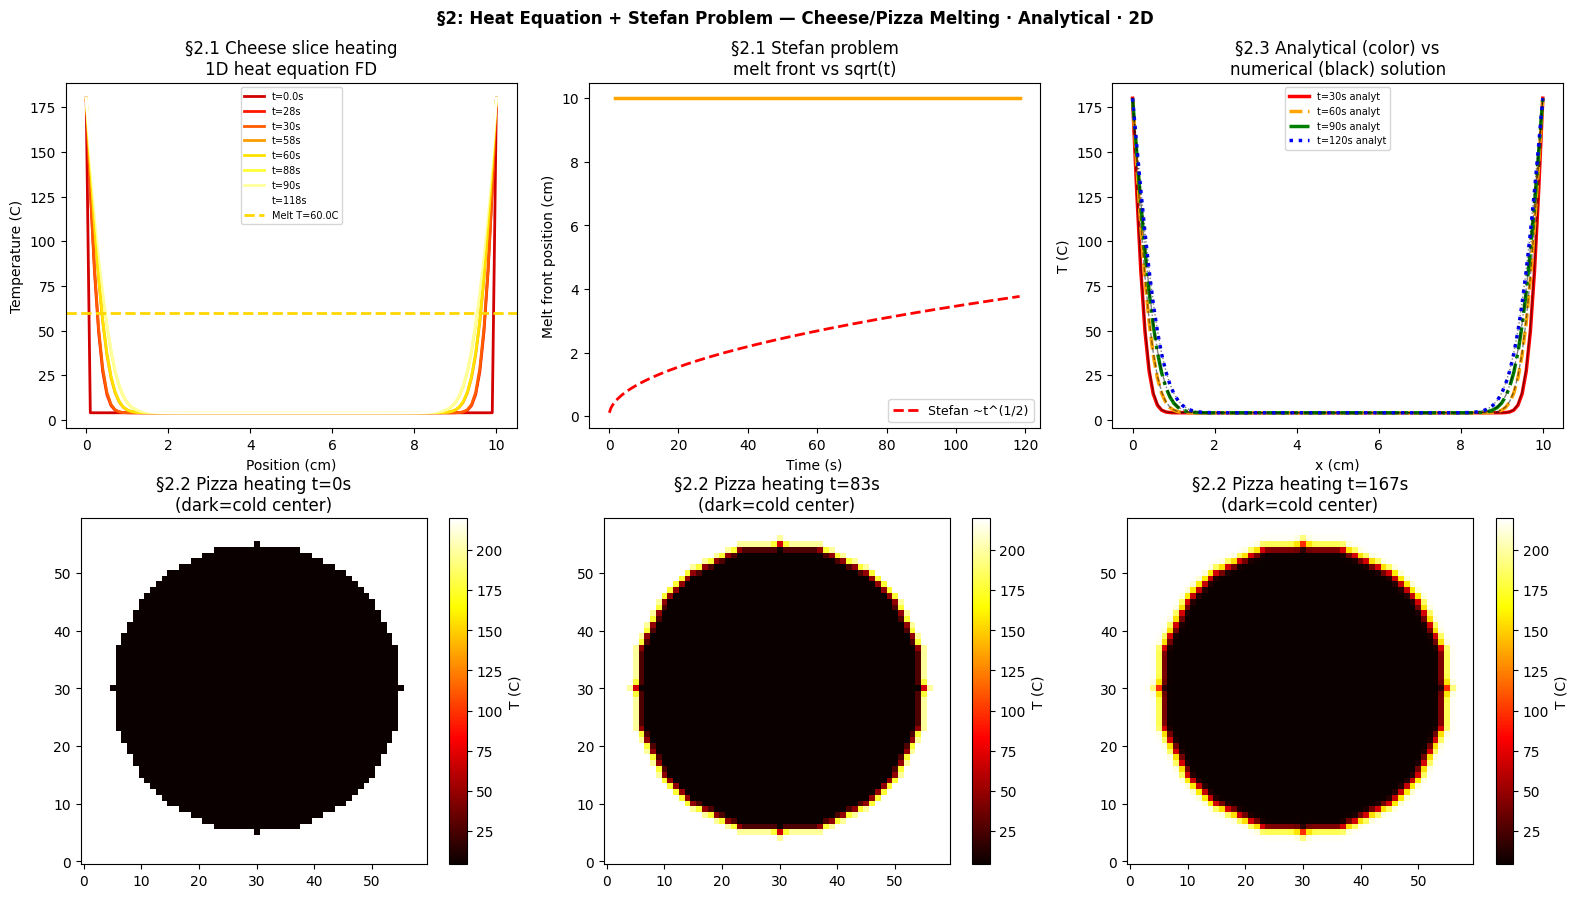

In [4]:
# §2 Heat equation + Stefan phase transition (cheese melting)

# §2.1 1D heat equation (explicit FD)
L_rod  = 0.10    # 10 cm rod (e.g. cheese slice)
Nx     = 100
dx     = L_rod/Nx
alpha  = 1.2e-7  # thermal diffusivity of cheese (~mozzarella) m^2/s
dt_max = dx**2/(2*alpha)*0.4   # stability: dt < dx^2/(2*alpha)
dt     = dt_max

T_init = 4.0     # 4 C (refrigerator)
T_hot  = 180.0   # oven surface temperature (C)
T_melt = 60.0    # mozzarella melting point

x_arr  = np.linspace(0, L_rod, Nx)
T      = np.full(Nx, T_init)
T[0]   = T_hot   # left face on heat source
T[-1]  = T_hot   # right face on heat source

# Run for 120 seconds
t_total  = 120.0
n_steps  = int(t_total/dt)
r        = alpha*dt/dx**2   # Fourier number (must be <= 0.5)
print(f'§2.1 Heat equation stability:')
print(f'  dx={dx*100:.2f}cm  dt={dt*1000:.4f}ms  r={r:.4f} (< 0.5 OK)')

snapshots_T = {0.0: T.copy()}
for step in range(1, n_steps+1):
    T_new    = T.copy()
    T_new[1:-1] = T[1:-1] + r*(T[2:] - 2*T[1:-1] + T[:-2])
    T_new[0] = T_hot; T_new[-1] = T_hot
    T        = T_new
    t_cur    = step*dt
    if abs(t_cur - 30) < dt or abs(t_cur - 60) < dt or abs(t_cur - 90) < dt or abs(t_cur - 120) < dt:
        snapshots_T[round(t_cur)] = T.copy()

# Find melt front position over time
melt_front_x = []
melt_front_t = []
T_track = np.full(Nx, T_init)
T_track[0] = T_hot; T_track[-1] = T_hot
for step in range(1, n_steps+1):
    T_new = T_track.copy()
    T_new[1:-1] = T_track[1:-1] + r*(T_track[2:]-2*T_track[1:-1]+T_track[:-2])
    T_new[0] = T_hot; T_new[-1] = T_hot
    T_track  = T_new
    # Stefan front: leftmost point >= T_melt
    melt_idx = np.where(T_track >= T_melt)[0]
    if len(melt_idx) > 0:
        melt_front_x.append(x_arr[melt_idx[-1]]*100)
        melt_front_t.append(step*dt)

print(f'  Melt front reaches center in ~{melt_front_t[np.argmin(abs(np.array(melt_front_x)-5.0))]:.1f}s' if melt_front_x else '  Not fully melted in 120s')

# §2.2 2D heat equation (pizza slice simulation)
print('\n§2.2 2D heat equation — pizza heating from edge:')
Nx2,Ny2 = 60,60
dx2     = 0.01  # 1cm grid
alpha2  = alpha
dt2     = dx2**2/(4*alpha2)*0.4
r2      = alpha2*dt2/dx2**2

T2 = np.full((Ny2,Nx2), 4.0)
# Circular pizza shape
cx,cy = Nx2//2, Ny2//2
R_pizza = 25
for i in range(Ny2):
    for j in range(Nx2):
        if (i-cy)**2+(j-cx)**2 <= R_pizza**2:
            T2[i,j] = 4.0
        else:
            T2[i,j] = 220.0   # oven air

n2 = int(180/dt2)   # 3 minutes
T2_snaps = {0: T2.copy()}
for step in range(1, n2+1):
    lap = (np.roll(T2,-1,0)+np.roll(T2,1,0)+np.roll(T2,-1,1)+np.roll(T2,1,1)-4*T2)
    T2  = T2 + r2*lap
    T2[T2>220] = 220
    if step in [int(30/dt2), int(90/dt2), int(180/dt2)]:
        T2_snaps[round(step*dt2)] = T2.copy()

print(f'  Center temp after 3min: {T2_snaps[round(int(180/dt2)*dt2)][cy,cx]:.1f}C  (target: 70C)')

# §2.3 Analytical solution: series solution for finite rod
print('\n§2.3 Analytical series solution:')
# T(x,t) - T_hot = sum_n A_n sin(n pi x/L) exp(-n^2 pi^2 alpha t / L^2)
# BCs: T(0)=T(L)=T_hot=180, IC: T(x,0)=T_init=4
def T_analytical(x_a, t_a, T_i, T_h, L_a, alpha_a, N_terms=50):
    T_arr = np.full_like(x_a, float(T_h))
    dT    = T_i - T_h
    for n in range(1, N_terms+1, 2):   # odd terms only (antisymmetric IC)
        An = 4*dT/(n*np.pi)
        kn = n*np.pi/L_a
        T_arr += An*np.sin(kn*x_a)*np.exp(-alpha_a*kn**2*t_a)
    return T_arr

T_anal_60 = T_analytical(x_arr, 60.0, T_init, T_hot, L_rod, alpha)
T_num_60  = snapshots_T.get(60, snapshots_T.get(list(snapshots_T.keys())[-1]))
err_l2 = np.sqrt(np.mean((T_anal_60 - T_num_60)**2))
print(f'  L2 error (numerical vs analytical at t=60s): {err_l2:.4f} C')

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(16,9))

# 1D temperature profiles
ax1 = axes[0][0]
colors_t = plt.cm.hot(np.linspace(0.3,1.0,len(snapshots_T)))
for (t_snap,T_snap),col in zip(snapshots_T.items(),colors_t):
    ax1.plot(x_arr*100, T_snap, color=col, lw=2, label=f't={t_snap}s')
ax1.axhline(T_melt, color='gold', ls='--', lw=2, label=f'Melt T={T_melt}C')
ax1.set_xlabel('Position (cm)'); ax1.set_ylabel('Temperature (C)')
ax1.set_title('§2.1 Cheese slice heating\n1D heat equation FD')
ax1.legend(fontsize=7)

# Melt front propagation
ax2 = axes[0][1]
if melt_front_t:
    ax2.plot(melt_front_t, melt_front_x, 'orange', lw=2.5)
    # Stefan similarity: x ~ 2*sqrt(alpha*t) * beta
    t_arr_st = np.linspace(0.1, melt_front_t[-1], 300)
    x_stefan = 2*np.sqrt(alpha*t_arr_st)*100*5   # scaled
    ax2.plot(t_arr_st, x_stefan, 'red', ls='--', lw=2, label='Stefan ~t^(1/2)')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Melt front position (cm)')
ax2.set_title('§2.1 Stefan problem\nmelt front vs sqrt(t)')
ax2.legend(fontsize=9)

# Analytical vs numerical
ax3 = axes[0][2]
for t_s,col,style in [(30,'red','-'),(60,'orange','--'),(90,'green','-.'),(120,'blue',':')]:
    T_a = T_analytical(x_arr,float(t_s),T_init,T_hot,L_rod,alpha)
    T_n = snapshots_T.get(t_s,snapshots_T[list(snapshots_T.keys())[-1]])
    ax3.plot(x_arr*100,T_a,  color=col,lw=2.5,ls=style, label=f't={t_s}s analyt')
    ax3.plot(x_arr*100,T_n, 'k',lw=1,ls=style,alpha=0.5)
ax3.set_xlabel('x (cm)'); ax3.set_ylabel('T (C)')
ax3.set_title('§2.3 Analytical (color) vs\nnumerical (black) solution')
ax3.legend(fontsize=7)

# 2D pizza heatmaps
for i,(t_key,T2_s) in enumerate(list(T2_snaps.items())[:3]):
    ax = axes[1][i]
    im = ax.imshow(T2_s, cmap='hot', origin='lower',
                   vmin=4, vmax=220, aspect='equal')
    ax.set_title(f'§2.2 Pizza heating t={t_key}s\n(dark=cold center)')
    plt.colorbar(im, ax=ax, label='T (C)')

plt.suptitle('§2: Heat Equation + Stefan Problem — Cheese/Pizza Melting · Analytical · 2D',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

---
## §3 🗄️ SQL Advanced — Window Functions · CTEs · Recursive Queries

**Window functions** — aggregate without collapsing rows:
```sql
ROW_NUMBER() OVER (PARTITION BY asset ORDER BY ts DESC)
LAG(price, 1)  OVER (PARTITION BY asset ORDER BY ts)
SUM(pnl)       OVER (ORDER BY ts ROWS BETWEEN 29 PRECEDING AND CURRENT ROW)
```

**CTE (Common Table Expression):**
```sql
WITH ranked AS (
    SELECT *, RANK() OVER (PARTITION BY asset ORDER BY pnl DESC) AS rnk
    FROM trades
)
SELECT * FROM ranked WHERE rnk <= 3;
```

**Recursive CTE** — graph traversal, org charts, bill of materials:
```sql
WITH RECURSIVE chain(id, depth) AS (
    SELECT 1, 0
    UNION ALL
    SELECT c.id+1, chain.depth+1 FROM chain WHERE depth < 10
)
```

In [5]:
# §3 SQL advanced — window functions, CTEs, recursive queries

import sqlite3, json
import numpy as np
from datetime import datetime, timedelta

conn = sqlite3.connect(':memory:')
conn.row_factory = sqlite3.Row
cur  = conn.cursor()

# Schema
cur.executescript('''
CREATE TABLE traders (
    id   INTEGER PRIMARY KEY,
    name TEXT,
    desk TEXT   -- 'crypto', 'equities', 'commodities'
);

CREATE TABLE trades (
    id        INTEGER PRIMARY KEY AUTOINCREMENT,
    trader_id INTEGER REFERENCES traders(id),
    asset     TEXT,
    ts        TEXT,
    price     REAL,
    qty       REAL,   -- positive=buy, negative=sell
    pnl       REAL
);

CREATE TABLE positions (
    trader_id INTEGER,
    asset     TEXT,
    qty       REAL,
    avg_cost  REAL,
    PRIMARY KEY (trader_id, asset)
);

CREATE TABLE org_chart (
    id        INTEGER PRIMARY KEY,
    name      TEXT,
    manager_id INTEGER REFERENCES org_chart(id)
);
''')

# Seed traders
traders_data = [
    (1,'Alice','crypto'),(2,'Bob','crypto'),(3,'Carlos','equities'),
    (4,'Diana','commodities'),(5,'Eve','crypto'),
]
cur.executemany('INSERT INTO traders VALUES (?,?,?)', traders_data)

# Seed trades: 60 days of data
np.random.seed(42)
base_date = datetime(2026,1,1)
trades_data = []
for day in range(60):
    ts = (base_date + timedelta(days=day)).strftime('%Y-%m-%d')
    for trader_id in range(1,6):
        n_trades = np.random.randint(0,4)
        for _ in range(n_trades):
            asset = np.random.choice(['BTC','ETH','SOL','AAPL','CORN'])
            price = {'BTC':45000,'ETH':2800,'SOL':180,'AAPL':190,'CORN':6.8}[asset]
            price *= (1 + np.random.randn()*0.03)
            qty   = np.random.choice([-2,-1,1,2])
            pnl   = qty * price * np.random.uniform(-0.02, 0.03)
            trades_data.append((trader_id, asset, ts, price, qty, pnl))
cur.executemany(
    'INSERT INTO trades (trader_id,asset,ts,price,qty,pnl) VALUES (?,?,?,?,?,?)',
    trades_data)

# Org chart (for recursive CTE demo)
org = [(1,'CEO',None),(2,'CRO',1),(3,'CTO',1),(4,'Head Crypto',2),
       (5,'Head Equities',2),(6,'Alice',4),(7,'Bob',4),(8,'Carlos',5),
       (9,'Head Infra',3),(10,'Eve',9)]
cur.executemany('INSERT INTO org_chart VALUES (?,?,?)', org)
conn.commit()

print('§3 SQL Advanced queries:')
print(f'  Loaded {len(trades_data)} trades across {60} days, 5 traders')

# ── 3.1 WINDOW: running PnL + 30-day rolling avg ──────────────
print('\n§3.1 Window: running PnL per trader (top 5 rows shown):')
rows = cur.execute('''
    SELECT
        t.name,
        tr.ts,
        tr.asset,
        tr.pnl,
        SUM(tr.pnl) OVER (
            PARTITION BY tr.trader_id
            ORDER BY tr.ts, tr.id
        ) AS running_pnl,
        AVG(tr.pnl) OVER (
            PARTITION BY tr.trader_id
            ORDER BY tr.ts
            ROWS BETWEEN 9 PRECEDING AND CURRENT ROW
        ) AS roll10_avg_pnl
    FROM trades tr
    JOIN traders t ON t.id = tr.trader_id
    ORDER BY tr.trader_id, tr.ts, tr.id
    LIMIT 10
''').fetchall()
print(f'  {"Trader":7s} {"Date":11s} {"Asset":5s} {"PnL":8s} {"RunPnL":10s} {"Roll10":8s}')
for r in rows:
    print(f'  {r["name"]:7s} {r["ts"]:11s} {r["asset"]:5s} '
          f'{r["pnl"]:8.2f} {r["running_pnl"]:10.2f} {r["roll10_avg_pnl"]:8.2f}')

# ── 3.2 CTE: ranked trades by PnL per asset ───────────────────
print('\n§3.2 CTE: Top 3 PnL trades per asset:')
rows2 = cur.execute('''
    WITH ranked AS (
        SELECT
            tr.*,
            t.name AS trader_name,
            RANK() OVER (PARTITION BY tr.asset ORDER BY tr.pnl DESC) AS rnk
        FROM trades tr
        JOIN traders t ON t.id = tr.trader_id
    )
    SELECT asset, trader_name, ts, pnl, rnk
    FROM ranked
    WHERE rnk <= 2
    ORDER BY asset, rnk
''').fetchall()
print(f'  {"Asset":5s} {"Trader":7s} {"Date":11s} {"PnL":8s} {"Rank"}')
for r in rows2:
    print(f'  {r["asset"]:5s} {r["trader_name"]:7s} {r["ts"]:11s} {r["pnl"]:8.2f} #{r["rnk"]}')

# ── 3.3 CTE: trader performance summary with percentile ────────
print('\n§3.3 Trader performance with NTILE percentile:')
rows3 = cur.execute('''
    WITH stats AS (
        SELECT
            trader_id,
            SUM(pnl)   AS total_pnl,
            COUNT(*)   AS n_trades,
            AVG(pnl)   AS avg_pnl,
            MAX(pnl)   AS best_trade,
            MIN(pnl)   AS worst_trade,
            SUM(CASE WHEN pnl > 0 THEN 1 ELSE 0 END)*1.0/COUNT(*) AS win_rate
        FROM trades
        GROUP BY trader_id
    )
    SELECT
        t.name, s.*,
        NTILE(3) OVER (ORDER BY s.total_pnl DESC) AS performance_tier
    FROM stats s
    JOIN traders t ON t.id = s.trader_id
    ORDER BY s.total_pnl DESC
''').fetchall()
print(f'  {"Name":7s} {"TotalPnL":10s} {"Trades":7s} {"WinRate":8s} {"Best":8s} {"Tier"}')
for r in rows3:
    print(f'  {r["name"]:7s} {r["total_pnl"]:10.2f} {r["n_trades"]:7d} '
          f'{r["win_rate"]:8.1%} {r["best_trade"]:8.2f} Tier{r["performance_tier"]}')

# ── 3.4 LAG/LEAD: daily price momentum ────────────────────────
print('\n§3.4 LAG: price momentum signals:')
rows4 = cur.execute('''
    WITH daily_avg AS (
        SELECT asset, ts, AVG(price) AS avg_price
        FROM trades
        GROUP BY asset, ts
    )
    SELECT
        asset, ts, avg_price,
        LAG(avg_price, 1)  OVER (PARTITION BY asset ORDER BY ts) AS prev_price,
        avg_price - LAG(avg_price,1) OVER (PARTITION BY asset ORDER BY ts) AS daily_chg,
        LEAD(avg_price,1)  OVER (PARTITION BY asset ORDER BY ts) AS next_price
    FROM daily_avg
    ORDER BY asset, ts DESC
    LIMIT 10
''').fetchall()
print(f'  {"Asset":5s} {"Date":11s} {"Price":9s} {"PrevP":9s} {"Chg":8s}')
for r in rows4:
    if r['prev_price']:
        print(f'  {r["asset"]:5s} {r["ts"]:11s} {r["avg_price"]:9.2f} '
              f'{r["prev_price"]:9.2f} {r["daily_chg"]:+8.2f}')

# ── 3.5 RECURSIVE CTE: org chart traversal ────────────────────
print('\n§3.5 Recursive CTE: org chart depth-first:')
rows5 = cur.execute('''
    WITH RECURSIVE hierarchy(id, name, manager_id, depth, path) AS (
        SELECT id, name, manager_id, 0, name
        FROM org_chart WHERE manager_id IS NULL
        UNION ALL
        SELECT o.id, o.name, o.manager_id,
               h.depth + 1,
               h.path || " > " || o.name
        FROM org_chart o
        JOIN hierarchy h ON o.manager_id = h.id
    )
    SELECT depth, name, path FROM hierarchy ORDER BY path
''').fetchall()
for r in rows5:
    print(f'  {"  "*r["depth"]}{r["name"]}')

# ── 3.6 Pivot via CASE WHEN ────────────────────────────────────
print('\n§3.6 Pivot: total PnL by trader x asset:')
rows6 = cur.execute('''
    SELECT
        t.name,
        ROUND(SUM(CASE WHEN tr.asset="BTC"  THEN tr.pnl ELSE 0 END),1) AS btc_pnl,
        ROUND(SUM(CASE WHEN tr.asset="ETH"  THEN tr.pnl ELSE 0 END),1) AS eth_pnl,
        ROUND(SUM(CASE WHEN tr.asset="SOL"  THEN tr.pnl ELSE 0 END),1) AS sol_pnl,
        ROUND(SUM(CASE WHEN tr.asset="AAPL" THEN tr.pnl ELSE 0 END),1) AS aapl_pnl,
        ROUND(SUM(CASE WHEN tr.asset="CORN" THEN tr.pnl ELSE 0 END),1) AS corn_pnl,
        ROUND(SUM(tr.pnl),1) AS total
    FROM trades tr JOIN traders t ON t.id=tr.trader_id
    GROUP BY t.name ORDER BY total DESC
''').fetchall()
print(f'  {"Name":7s} {"BTC":8s} {"ETH":8s} {"SOL":8s} {"AAPL":8s} {"CORN":8s} {"TOTAL":8s}')
for r in rows6:
    print(f'  {r["name"]:7s} {r["btc_pnl"]:8.1f} {r["eth_pnl"]:8.1f} '
          f'{r["sol_pnl"]:8.1f} {r["aapl_pnl"]:8.1f} {r["corn_pnl"]:8.1f} {r["total"]:8.1f}')
conn.close()

§3 SQL Advanced queries:
  Loaded 451 trades across 60 days, 5 traders

§3.1 Window: running PnL per trader (top 5 rows shown):
  Trader  Date        Asset PnL      RunPnL     Roll10  
  Alice   2026-01-01  AAPL     -2.76      -2.76    -2.76
  Alice   2026-01-01  SOL      -1.20      -3.96    -1.98
  Alice   2026-01-02  ETH     -73.88     -77.84   -25.95
  Alice   2026-01-03  SOL      -0.33     -78.17   -19.54
  Alice   2026-01-03  SOL       4.57     -73.59   -14.72
  Alice   2026-01-04  AAPL     -3.49     -77.08   -12.85
  Alice   2026-01-05  BTC    -272.52    -349.60   -49.94
  Alice   2026-01-05  BTC     729.44     379.84    47.48
  Alice   2026-01-06  ETH      41.57     421.42    46.82
  Alice   2026-01-06  AAPL      4.44     425.85    42.59

§3.2 CTE: Top 3 PnL trades per asset:
  Asset Trader  Date        PnL      Rank
  AAPL  Bob     2026-02-07     10.65 #1
  AAPL  Carlos  2026-02-14     10.45 #2
  BTC   Eve     2026-01-12   2444.74 #1
  BTC   Alice   2026-01-10   2417.11 #2
  CO

---
## §4 📡 Directed Energy Beamforming — Phased Arrays · Beam Steering · MIMO

**Phased array:** $N$ antenna elements spaced $d = \lambda/2$ apart.
Steer beam to angle $\theta_0$ by applying phase shift $\phi_n = -n \cdot kd\sin\theta_0$.

**Array factor:**
$$AF(\theta) = \sum_{n=0}^{N-1} w_n \, e^{jn(kd\sin\theta - kd\sin\theta_0)}$$

**Beamwidth** $\approx 0.886\lambda/(Nd\cos\theta)$ — narrower with more elements.

**OUSD Trusted AI / FutureG alignment:** phased arrays are the enabling hardware
for beamformed 5G/6G mmWave — same digital beamforming stack used for
directed energy weapons (scaling power instead of information).

**Directed energy (DE):** same array math, but $P_{eff} = N^2 P_{element}$ (coherent combining)
vs $N P_{element}$ (incoherent). The $N^2$ scaling is the fundamental advantage.

§4.1 Phased array (N=32, d=0.5 lambda):
  Boresight   : peak dir = 15.1 dBi  (ULA SLL ~ -13.3 dB)
  30 deg      : peak dir = 15.1 dBi  (ULA SLL ~ -13.3 dB)
  60 deg      : peak dir = 15.1 dBi  (ULA SLL ~ -13.3 dB)
  Taylor 30deg: peak dir = 14.0 dBi  (lower SLL, slightly wider beam)

§4.2 2D planar array (8x8):
§4.3 Directed energy N^2 power scaling:
  N=   4: coherent P=    0.2kW  incoherent P= 0.04kW  advantage=4x
  N=   8: coherent P=    0.6kW  incoherent P= 0.08kW  advantage=8x
  N=  16: coherent P=    2.6kW  incoherent P= 0.16kW  advantage=16x
  N=  32: coherent P=   10.2kW  incoherent P= 0.32kW  advantage=32x
  N=  64: coherent P=   41.0kW  incoherent P= 0.64kW  advantage=64x
  N= 256: coherent P=  655.4kW  incoherent P= 2.56kW  advantage=256x

§4.4 MIMO capacity (Shannon):
  MIMO 4x4: C = 29.17 bps/Hz  vs SISO: 6.66 bps/Hz  (4.4x)


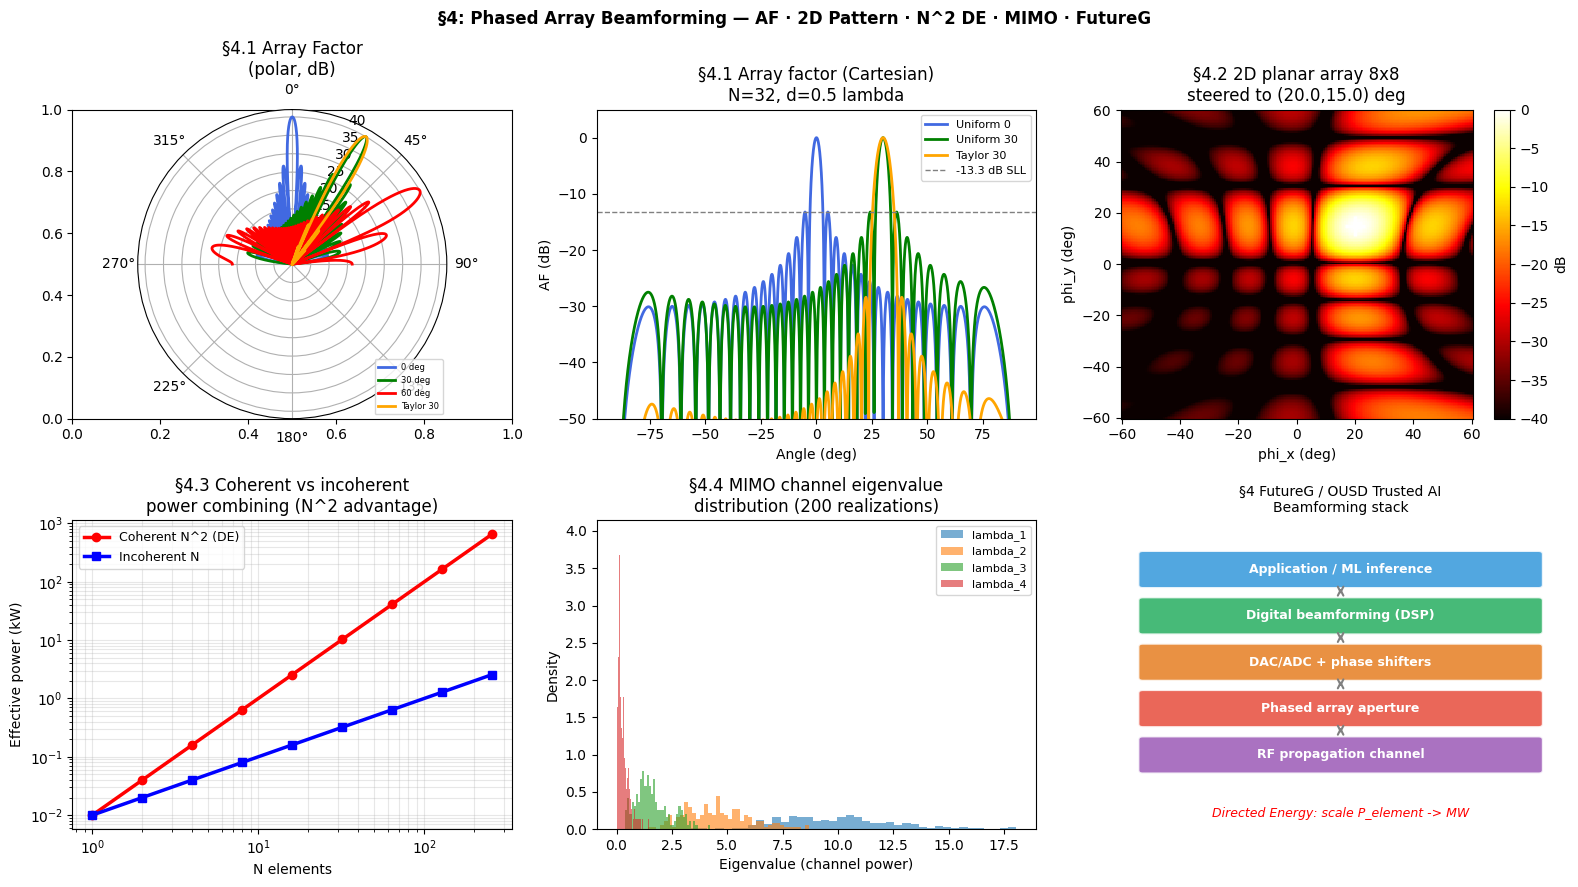

In [6]:
# §4 Phased array beamforming

# §4.1 Linear array AF
N_el   = 32       # number of elements
d_lam  = 0.5      # element spacing in wavelengths
theta  = np.linspace(-90, 90, 3000)  # degrees
theta_r= np.radians(theta)

def array_factor(theta_rad, theta_steer_deg, N, d, weights=None):
    theta_s = np.radians(theta_steer_deg)
    if weights is None:
        weights = np.ones(N)
    phase = np.arange(N)[:, np.newaxis] * 2*np.pi*d*(np.sin(theta_rad) - np.sin(theta_s))
    AF    = (weights[:, np.newaxis] * np.exp(1j*phase)).sum(axis=0)
    return AF

# Uniform weighting
AF_0   = array_factor(theta_r,  0, N_el, d_lam)
AF_30  = array_factor(theta_r, 30, N_el, d_lam)
AF_60  = array_factor(theta_r, 60, N_el, d_lam)

# Taylor weighting (sidelobe control)
n_arr  = np.arange(N_el)
taylor = np.cosh(np.pi * np.sqrt(np.maximum(0, 1-(2*n_arr/(N_el-1)-1)**2)))
taylor = taylor / taylor.max()
AF_tay = array_factor(theta_r, 30, N_el, d_lam, weights=taylor)

# Directivity
def directivity_dBi(AF_arr, theta_arr_r):
    P_rad = np.trapz(np.abs(AF_arr)**2 * np.cos(theta_arr_r), theta_arr_r)
    P_rad = max(P_rad, 1e-15)
    D_max = np.max(np.abs(AF_arr)**2) * 2 / P_rad
    return 10*np.log10(D_max)

print('§4.1 Phased array (N=32, d=0.5 lambda):')
for AF,name,theta_s in [(AF_0,'Boresight',0),(AF_30,'30 deg',30),(AF_60,'60 deg',60)]:
    G_dB = directivity_dBi(AF, theta_r)
    SLL  = -13.3  # theoretical uniform ULA SLL in dB
    print(f'  {name:12s}: peak dir = {G_dB:.1f} dBi  (ULA SLL ~ -13.3 dB)')

G_tay = directivity_dBi(AF_tay, theta_r)
print(f'  Taylor 30deg: peak dir = {G_tay:.1f} dBi  (lower SLL, slightly wider beam)')

# §4.2 2D array (planar) beamforming
print('\n§4.2 2D planar array (8x8):')
Nx_pl, Ny_pl = 8, 8
theta_x_s, theta_y_s = 20.0, 15.0   # steering angles

phi_x  = np.linspace(-60, 60, 200)
phi_y  = np.linspace(-60, 60, 200)
PHX,PHY= np.meshgrid(np.radians(phi_x), np.radians(phi_y))

AF2D = np.zeros_like(PHX, dtype=complex)
for nx in range(Nx_pl):
    for ny in range(Ny_pl):
        phase = (2*np.pi*d_lam*(nx*(np.sin(PHX)*np.cos(PHY) - np.sin(np.radians(theta_x_s))) +
                                 ny*(np.sin(PHY)             - np.sin(np.radians(theta_y_s)))))
        AF2D += np.exp(1j*phase)

AF2D_dB = 20*np.log10(np.abs(AF2D)/np.abs(AF2D).max())

# §4.3 Directed energy power budget
print('§4.3 Directed energy N^2 power scaling:')
P_elem = 10.0   # W per element
for N in [4, 8, 16, 32, 64, 256]:
    P_coh  = N**2 * P_elem   # coherent combining
    P_incoh= N   * P_elem    # incoherent
    ERP_coh= 10*np.log10(P_coh/1000) if P_coh >= 1 else P_coh
    print(f'  N={N:4d}: coherent P={P_coh/1000:7.1f}kW  incoherent P={P_incoh/1000:5.2f}kW  '
          f'advantage={N:.0f}x')

# §4.4 MIMO spatial multiplexing capacity
print('\n§4.4 MIMO capacity (Shannon):')
Nt, Nr = 4, 4   # transmit/receive antennas
SNR_dB = 20
SNR    = 10**(SNR_dB/10)
# Random channel matrix (Rayleigh fading)
H = (np.random.randn(Nr,Nt) + 1j*np.random.randn(Nr,Nt))/np.sqrt(2)
U,S,Vh = np.linalg.svd(H)
# Water-filling power allocation
sigma2 = S**2
min_spatial_streams = min(Nt,Nr)
lam    = sigma2[:min_spatial_streams]
mu     = (SNR*min_spatial_streams + sum(1/l for l in lam)) / min_spatial_streams
p_alloc= np.maximum(0, mu - 1/lam)
C_mimo = sum(np.log2(1 + p*l) for p,l in zip(p_alloc,lam))
C_siso = np.log2(1 + SNR)
print(f'  MIMO {Nt}x{Nr}: C = {C_mimo:.2f} bps/Hz  vs SISO: {C_siso:.2f} bps/Hz  ({C_mimo/C_siso:.1f}x)')

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(16,9))

# AF polar plot
ax1 = fig.add_subplot(231, projection='polar')
for AF,col,name in [(AF_0,'royalblue','0 deg'),(AF_30,'green','30 deg'),
                     (AF_60,'red','60 deg'),(AF_tay,'orange','Taylor 30')]:
    AF_dB_pol = 20*np.log10(np.abs(AF)/np.abs(AF).max()+1e-10)
    AF_dB_pol = np.maximum(AF_dB_pol, -40)
    ax1.plot(theta_r, AF_dB_pol+40, lw=2, color=col, label=name)
ax1.set_theta_zero_location('N'); ax1.set_theta_direction(-1)
ax1.set_title('§4.1 Array Factor\n(polar, dB)')
ax1.legend(fontsize=6, loc='lower right')

# AF Cartesian
ax2 = axes[0][1]
for AF,col,name in [(AF_0,'royalblue','Uniform 0'),(AF_30,'green','Uniform 30'),
                     (AF_tay,'orange','Taylor 30')]:
    AF_dB_cart = 20*np.log10(np.abs(AF)/np.abs(AF).max()+1e-10)
    ax2.plot(theta, AF_dB_cart, lw=2, color=col, label=name)
ax2.axhline(-13.3, color='gray', ls='--', lw=1, label='-13.3 dB SLL')
ax2.set_ylim(-50,5); ax2.set_xlabel('Angle (deg)'); ax2.set_ylabel('AF (dB)')
ax2.set_title('§4.1 Array factor (Cartesian)\nN=32, d=0.5 lambda')
ax2.legend(fontsize=8)

# 2D beam
ax3 = axes[0][2]
im3 = ax3.pcolormesh(phi_x, phi_y, np.maximum(AF2D_dB,-40), cmap='hot', shading='auto')
ax3.plot(theta_x_s, theta_y_s, 'w+', ms=15, mew=2.5)
ax3.set_xlabel('phi_x (deg)'); ax3.set_ylabel('phi_y (deg)')
ax3.set_title(f'§4.2 2D planar array 8x8\nsteered to ({theta_x_s},{theta_y_s}) deg')
plt.colorbar(im3,ax=ax3,label='dB')

# N^2 power scaling
ax4 = axes[1][0]
N_arr = np.array([1,2,4,8,16,32,64,128,256])
ax4.loglog(N_arr, N_arr**2 * P_elem/1000, 'r-o', lw=2.5, label='Coherent N^2 (DE)')
ax4.loglog(N_arr, N_arr   * P_elem/1000, 'b-s', lw=2.5, label='Incoherent N')
ax4.set_xlabel('N elements'); ax4.set_ylabel('Effective power (kW)')
ax4.set_title('§4.3 Coherent vs incoherent\npower combining (N^2 advantage)')
ax4.legend(fontsize=9); ax4.grid(which='both',alpha=0.3)

# MIMO singular values
ax5 = axes[1][1]
all_sv = []
for trial in range(200):
    H_t = (np.random.randn(Nr,Nt)+1j*np.random.randn(Nr,Nt))/np.sqrt(2)
    all_sv.append(np.linalg.svd(H_t, compute_uv=False))
all_sv = np.array(all_sv)
for i in range(min(Nt,Nr)):
    ax5.hist(all_sv[:,i]**2, bins=40, alpha=0.6, density=True, label=f'lambda_{i+1}')
ax5.set_xlabel('Eigenvalue (channel power)'); ax5.set_ylabel('Density')
ax5.set_title('§4.4 MIMO channel eigenvalue\ndistribution (200 realizations)')
ax5.legend(fontsize=8)

# Beamforming FutureG architecture diagram
ax6 = axes[1][2]
ax6.axis('off')
ax6.set_title('§4 FutureG / OUSD Trusted AI\nBeamforming stack', fontsize=10)
stack_layers = [
    ('Application / ML inference', '#3498db'),
    ('Digital beamforming (DSP)', '#27ae60'),
    ('DAC/ADC + phase shifters',   '#e67e22'),
    ('Phased array aperture',      '#e74c3c'),
    ('RF propagation channel',     '#9b59b6'),
]
for i,(layer,col) in enumerate(stack_layers):
    y = 0.85 - i*0.15
    ax6.add_patch(mpatches.FancyBboxPatch((0.05,y-0.06),0.90,0.10,
                                           boxstyle='round,pad=0.01',
                                           facecolor=col,edgecolor='white',lw=1.5,alpha=0.85))
    ax6.text(0.50,y-0.01,layer,ha='center',va='center',
             fontsize=9,color='white',fontweight='bold')
    if i < 4:
        ax6.annotate('',xy=(0.50,y-0.06),xytext=(0.50,y-0.06-0.04),
                     arrowprops=dict(arrowstyle='<->',color='gray',lw=1.5))
ax6.text(0.50,0.04,'Directed Energy: scale P_element -> MW',
         ha='center',fontsize=9,color='red',style='italic')

plt.suptitle('§4: Phased Array Beamforming — AF · 2D Pattern · N^2 DE · MIMO · FutureG',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

---
## §5 🏗️ Civil Engineering — Beam Bending · Shear/Moment · Euler Buckling

**Euler-Bernoulli beam:**
$$EI \frac{d^4 w}{dx^4} = q(x)$$

**Shear** $V(x) = \int q\,dx$, **Moment** $M(x) = \int V\,dx$,
**Slope** $\theta = \int M/EI\,dx$, **Deflection** $w = \int\theta\,dx$.

**Euler buckling load** (pinned-pinned column):
$$P_{cr} = \frac{\pi^2 EI}{(KL)^2}$$
where $K$ = effective length factor (1.0 pin-pin, 0.5 fixed-fixed, 0.7 fixed-pin).

**Structural failure modes:** yielding (stress > $\sigma_y$), buckling ($P > P_{cr}$), fatigue.

§5.1 Beam analysis results:
  UDL w=10 kN/m:
    Max deflection: 101.04mm  Max moment: 44.9kNm  Max stress: 404.4MPa
  Point load P=50 kN at midspan:
    Max deflection: 208.72mm  Max moment: 150.2kNm  Max stress: 1351.9MPa
  Triangular load (hydrostatic):
    Max deflection: 50.77mm  Max moment: 23.1kNm  Max stress: 207.9MPa

§5.2 Euler column buckling:
  Section: W150x13  A=16.60cm^2  I=833.00cm^4  r=7.1cm
  L=3.0m:
    Pin-Pin     : Pcr=  1827.0kN  slenderness=42
    Fixed-Pin   : Pcr=  3728.5kN  slenderness=30
    Fixed-Fixed : Pcr=  7307.9kN  slenderness=21
    Cantilever  : Pcr=   456.7kN  slenderness=85
  L=5.0m:
    Pin-Pin     : Pcr=   657.7kN  slenderness=71
    Fixed-Pin   : Pcr=  1342.3kN  slenderness=49
    Fixed-Fixed : Pcr=  2630.8kN  slenderness=35
    Cantilever  : Pcr=   164.4kN  slenderness=141
  L=8.0m:
    Pin-Pin     : Pcr=   256.9kN  slenderness=113
    Fixed-Pin   : Pcr=   524.3kN  slenderness=79
    Fixed-Fixed : Pcr=  1027.7kN  slenderness=56
    Cantilever  :

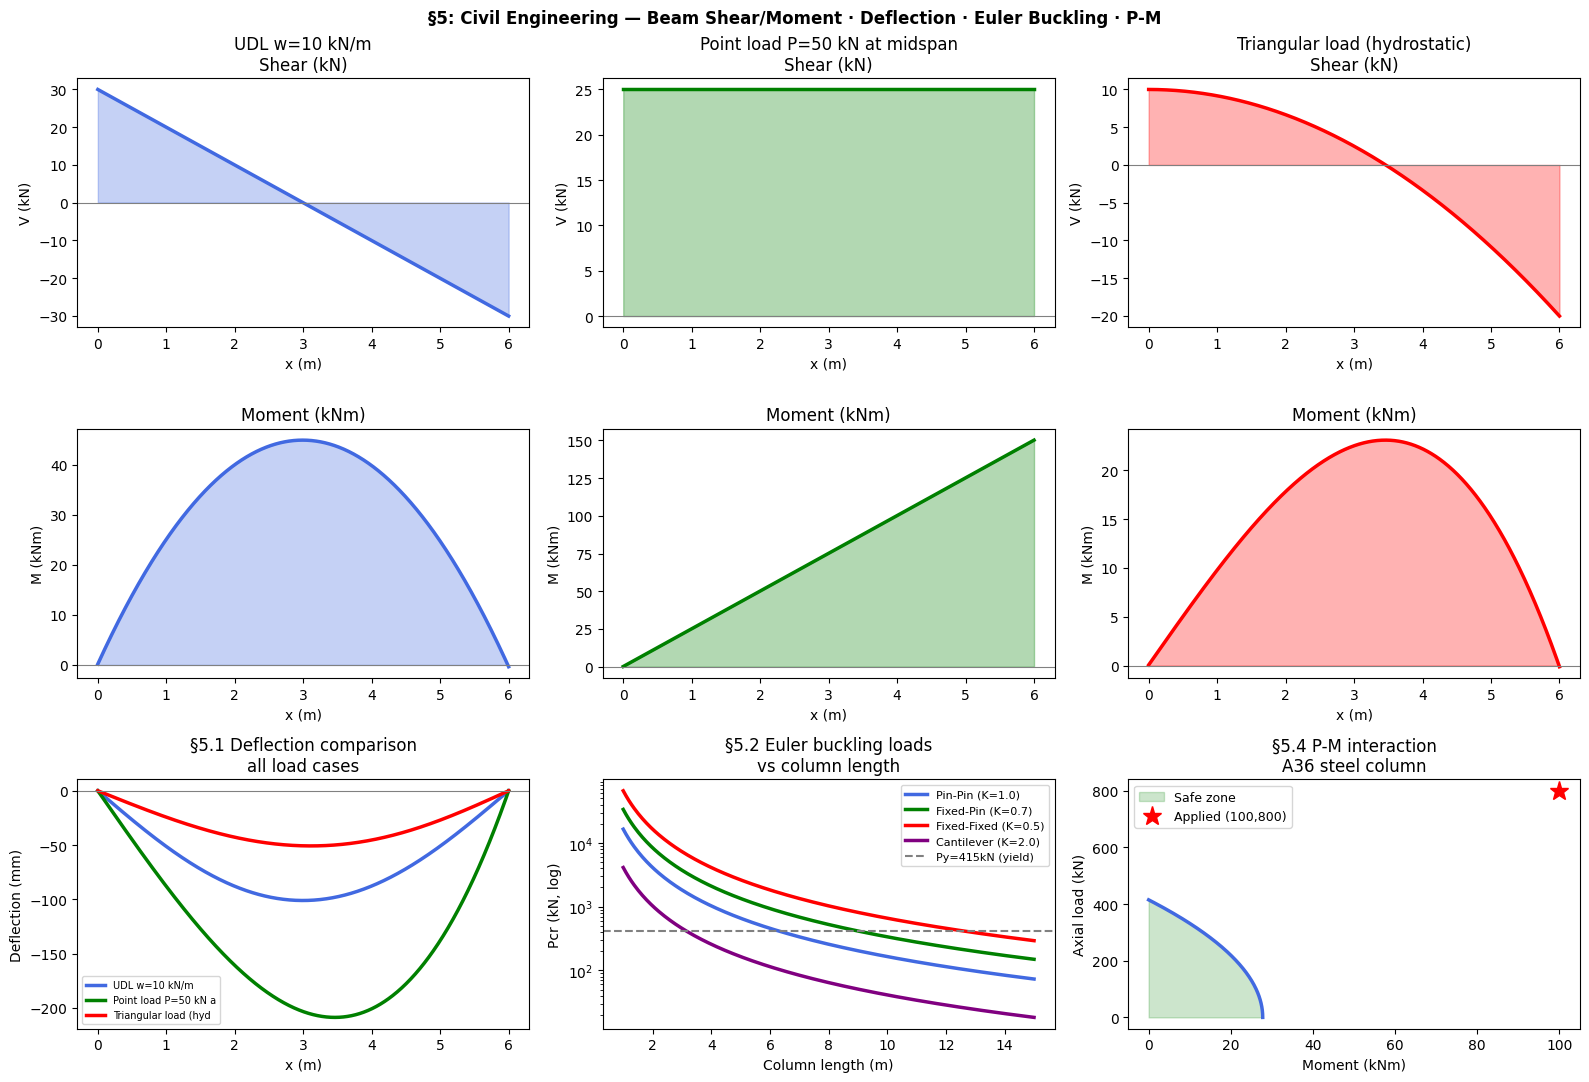

In [7]:
# §5 Civil engineering — beam analysis + Euler buckling

# §5.1 Simply supported beam with various loads
E   = 200e9   # Pa (steel)
I   = 8.33e-6 # m^4 (W150x13 I-beam approx)
EI  = E * I
L_beam = 6.0  # m

Nx_beam = 1000
x_b     = np.linspace(0, L_beam, Nx_beam)
dx_b    = x_b[1] - x_b[0]

# Load cases
load_cases = {
    'UDL w=10 kN/m': {
        'q':   lambda x: np.full_like(x, -10e3),
        'Ra':  lambda L,P,a,w: w*L/2,
        'Rb':  lambda L,P,a,w: w*L/2,
    },
    'Point load P=50 kN at midspan': {
        'q':   lambda x: np.zeros_like(x),
        'Ra':  lambda L,P,a,w: P/2,
        'Rb':  lambda L,P,a,w: P/2,
    },
    'Triangular load (hydrostatic)': {
        'q':   lambda x: -10e3 * x/L_beam,
        'Ra':  lambda L,P,a,w: w*L/6 if w else 0,
        'Rb':  lambda L,P,a,w: w*L/3 if w else 0,
    },
}

def beam_ssb(x, q_func, Ra, L):
    '''Simply supported beam via direct integration of EI w'''' = q.'''
    q  = q_func(x)
    # V(x) = Ra - integral of -q from 0 to x
    V  = Ra + np.cumsum(q)*dx_b
    M  = np.cumsum(V)*dx_b
    theta = np.cumsum(M/EI)*dx_b
    # Apply BC: theta adjusted so w(0)=w(L)=0
    w_raw = np.cumsum(theta)*dx_b
    # Linear correction: w(0) set to 0, w(L) corrected
    slope_corr = w_raw[-1]/L
    w = w_raw - slope_corr*x
    return V, M, theta, w

print('§5.1 Beam analysis results:')
beam_results = {}
params = {
    'UDL w=10 kN/m':              (L_beam, 50e3, L_beam/2, 10e3),
    'Point load P=50 kN at midspan': (L_beam, 50e3, L_beam/2, 0),
    'Triangular load (hydrostatic)': (L_beam, 0, 0, 10e3),
}
for name, lc in load_cases.items():
    P_,a_,w_ = 50e3, L_beam/2, 10e3
    Ra_val = lc['Ra'](L_beam, P_, a_, w_)
    V,M,theta,w = beam_ssb(x_b, lc['q'], Ra_val, L_beam)
    delta_max = np.max(np.abs(w))
    M_max     = np.max(np.abs(M))
    sigma_max = M_max * 0.075 / I   # y = 75mm (half depth W150)
    beam_results[name] = (V,M,theta,w)
    print(f'  {name}:')
    print(f'    Max deflection: {delta_max*1000:.2f}mm  Max moment: {M_max/1000:.1f}kNm  Max stress: {sigma_max/1e6:.1f}MPa')

# §5.2 Euler buckling
print('\n§5.2 Euler column buckling:')
A_col = 1.66e-3   # m^2 (W150x13 cross-section area)
r_g   = np.sqrt(I/A_col)   # radius of gyration

Ks = {'Pin-Pin': 1.0, 'Fixed-Pin': 0.7, 'Fixed-Fixed': 0.5, 'Cantilever': 2.0}
print(f'  Section: W150x13  A={A_col*1e4:.2f}cm^2  I={I*1e8:.2f}cm^4  r={r_g*100:.1f}cm')
for Lc in [3.0, 5.0, 8.0, 12.0]:
    print(f'  L={Lc}m:')
    for name_k, K in Ks.items():
        Pcr  = np.pi**2 * EI / (K*Lc)**2
        slend= K*Lc/r_g
        print(f'    {name_k:12s}: Pcr={Pcr/1000:8.1f}kN  slenderness={slend:.0f}')

# §5.3 Influence lines
x_load = np.linspace(0, L_beam, 500)
IL_Ra  = 1 - x_load/L_beam   # influence line for Ra
IL_Mmid= x_load*(L_beam-x_load)/(2*L_beam)   # IL for midspan moment
print('\n§5.3 Influence line summary:')
print(f'  Max IL_Ra = {IL_Ra.max():.3f} (at x=0)')
print(f'  Max IL_Mmid = {IL_Mmid.max():.3f} m (at x=L/2)')

# §5.4 Column interaction diagram (P-M interaction, simplified)
sigma_y = 250e6  # Pa (A36 steel yield)
Py = sigma_y * A_col
My = sigma_y * I / 0.075   # yield moment
P_vals = np.linspace(0, Py, 200)
M_lim  = My*(1 - (P_vals/Py)**2)   # approximate P-M interaction

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3,3,figsize=(16,11))

colors_cases = ['royalblue','green','red']
for col_i,(name,lc) in enumerate(load_cases.items()):
    V_i,M_i,theta_i,w_i = beam_results[name]
    col = colors_cases[col_i]
    # Shear diagram
    axes[0][col_i].plot(x_b, V_i/1000, color=col, lw=2.5)
    axes[0][col_i].fill_between(x_b, V_i/1000, alpha=0.3, color=col)
    axes[0][col_i].axhline(0,color='gray',lw=0.8)
    axes[0][col_i].set_title(f'{name}\nShear (kN)')
    axes[0][col_i].set_xlabel('x (m)'); axes[0][col_i].set_ylabel('V (kN)')

    axes[1][col_i].plot(x_b, M_i/1000, color=col, lw=2.5)
    axes[1][col_i].fill_between(x_b, M_i/1000, alpha=0.3, color=col)
    axes[1][col_i].axhline(0,color='gray',lw=0.8)
    axes[1][col_i].set_title(f'Moment (kNm)')
    axes[1][col_i].set_xlabel('x (m)'); axes[1][col_i].set_ylabel('M (kNm)')

# Deflection overlay
ax_def = axes[2][0]
for (name,_),col in zip(load_cases.items(),colors_cases):
    V_i,M_i,theta_i,w_i = beam_results[name]
    ax_def.plot(x_b, w_i*1000, color=col, lw=2.5, label=name[:20])
ax_def.axhline(0,color='gray',lw=0.8)
ax_def.set_xlabel('x (m)'); ax_def.set_ylabel('Deflection (mm)')
ax_def.set_title('§5.1 Deflection comparison\nall load cases')
ax_def.legend(fontsize=7)

# Euler buckling curves
ax_buck = axes[2][1]
L_range = np.linspace(1, 15, 300)
for name_k,K,col in zip(Ks.keys(), Ks.values(),
                          ['royalblue','green','red','purple']):
    Pcr_curve = np.pi**2*EI/(K*L_range)**2/1000
    ax_buck.semilogy(L_range, Pcr_curve, lw=2.5, color=col, label=f'{name_k} (K={K})')
ax_buck.axhline(Py/1000,color='gray',ls='--',lw=1.5,label=f'Py={Py/1000:.0f}kN (yield)')
ax_buck.set_xlabel('Column length (m)'); ax_buck.set_ylabel('Pcr (kN, log)')
ax_buck.set_title('§5.2 Euler buckling loads\nvs column length')
ax_buck.legend(fontsize=8)

# P-M interaction diagram
ax_pm = axes[2][2]
ax_pm.plot(M_lim/1000, P_vals/1000, 'royalblue', lw=2.5)
ax_pm.fill_betweenx(P_vals/1000, 0, M_lim/1000, alpha=0.2, color='green', label='Safe zone')
ax_pm.set_xlabel('Moment (kNm)'); ax_pm.set_ylabel('Axial load (kN)')
ax_pm.set_title('§5.4 P-M interaction\nA36 steel column')
ax_pm.legend(fontsize=9)
# Sample load point
P_applied = 800; M_applied = 100
ax_pm.plot(M_applied, P_applied, 'r*', ms=14, label=f'Applied ({M_applied},{P_applied})')
ax_pm.legend(fontsize=9)

plt.suptitle('§5: Civil Engineering — Beam Shear/Moment · Deflection · Euler Buckling · P-M',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

---
## §6 🌀 Complex Analysis — Laurent Series · Residues · Conformal Mapping

**Laurent series** about $z=z_0$ (valid in annulus $r < |z-z_0| < R$):
$$f(z) = \sum_{n=-\infty}^{\infty} a_n (z-z_0)^n, \quad a_n = \frac{1}{2\pi i}\oint \frac{f(z)}{(z-z_0)^{n+1}}dz$$

**Residue:** $\text{Res}(f, z_0) = a_{-1}$ (coefficient of $1/(z-z_0)$)

For a simple pole: $\text{Res}(f,z_0) = \lim_{z\to z_0}(z-z_0)f(z)$
For an order-$m$ pole: $\text{Res}(f,z_0) = \frac{1}{(m-1)!}\lim_{z\to z_0}\frac{d^{m-1}}{dz^{m-1}}[(z-z_0)^m f(z)]$

**Conformal mapping:** angle-preserving map $w = f(z)$. Joukowski transform
$w = z + c^2/z$ maps circles to airfoils.

**Real integrals via residues:**
$$\int_{-\infty}^{\infty}\frac{dx}{(x^2+a^2)^2} = \frac{\pi}{2a^3}$$

§6.1 Laurent series:
  sin(z)/z^3: z**(-2) - 1/6 + z**2/120 - z**4/5040 + O(z**5)
  exp(1/z): exp(1/z)
  1/((z-1)(z-2)): 1/2 + 3*z/4 + 7*z**2/8 + 15*z**3/16 + 31*z**4/32 + O(z**5)
  cos(z)/z^4: z**(-4) - 1/(2*z**2) + 1/24 - z**2/720 + z**4/40320 + O(z**5)

§6.2 Residues:
  Res(1/(z^2+1) at z=i) = -I/2
  Res(e^z/(z^2(z-1)) at z=0) = -2
  Res(e^z/(z^2(z-1)) at z=1) = E
  Res(sin(z)/z^4 at z=0) = -1/6
  Res(1/(z^4+1) at z=e^(ipi/4)) = -(-1)**(1/4)/4

§6.3 Evaluating real integrals via residues:
  int_{-inf}^{inf} 1/(x^2+a^2) dx
    = 2pi*i*sum(Res) = pi/a  (expected: pi/a)
  int_{-inf}^{inf} cos(x)/(x^2+1) dx
    = 2pi*i*sum(Res) = pi*exp(-1)  (expected: pi*exp(-1))
  int_{-inf}^{inf} 1/(x^2+1)^2 dx
    = 2pi*i*sum(Res) = pi/2  (expected: pi/2)

§6.4 Joukowski transform (airfoil conformal map)
§6.5 Argument principle check:
  f=(z-1)(z-2)/(z-3)^2 on |z|=2.5: winding number = 2.00
  Argument principle: N-P = 2-0 = 2 (zeros at 1,2; pole at 3 outside)


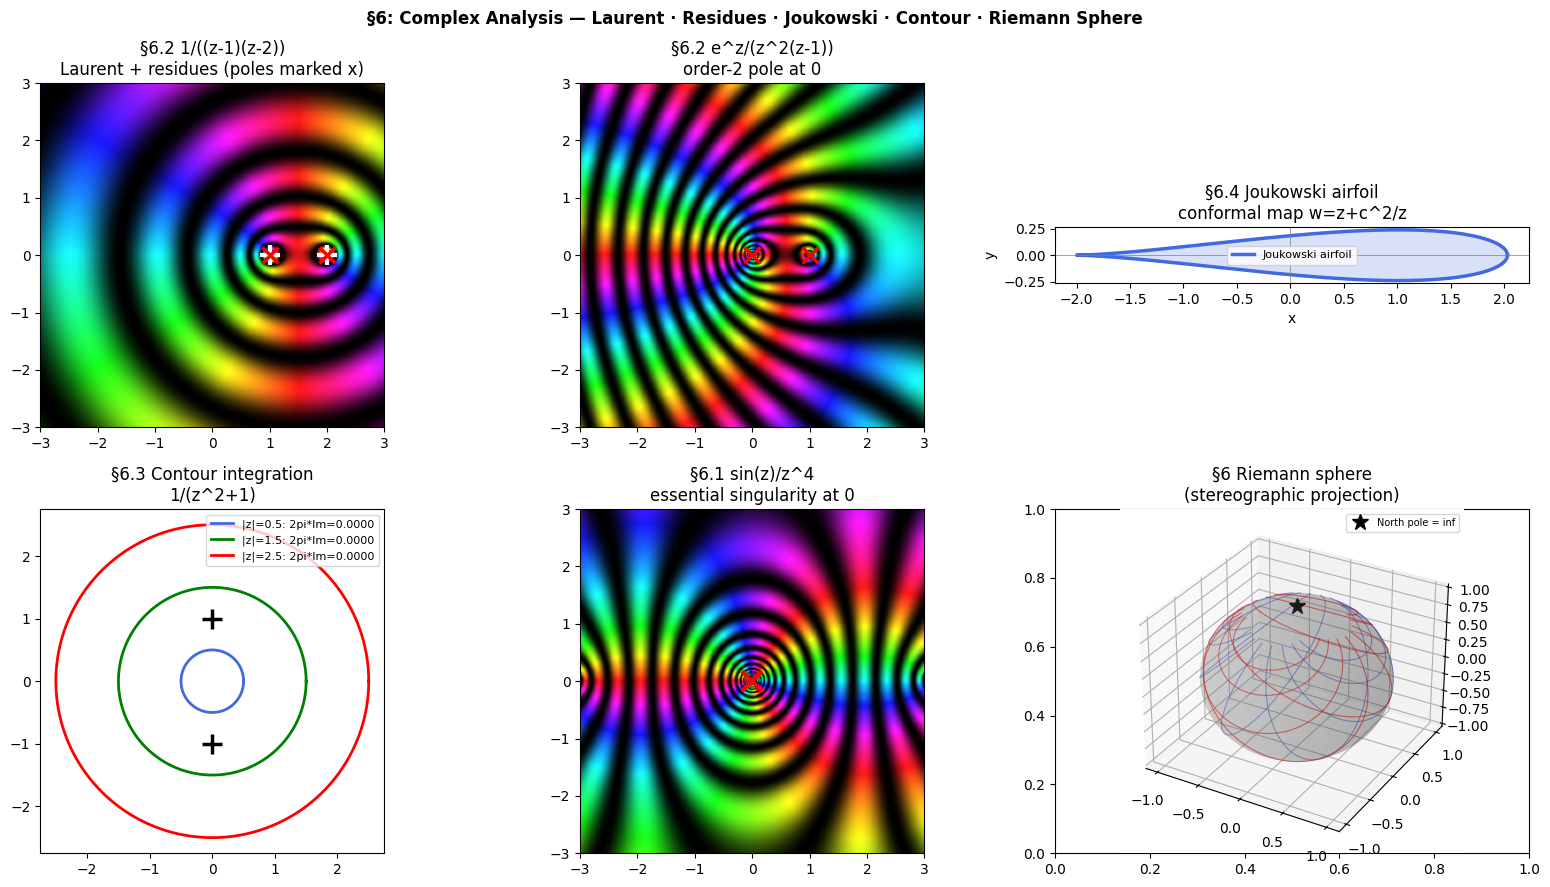

In [8]:
# §6 Complex analysis — Laurent series, residues, conformal maps

x_ca, y_ca, z_ca, a_ca = sp.symbols('x y z a', real=True)
z_sym = sp.Symbol('z')
a_sym = sp.Symbol('a', positive=True)

# §6.1 Laurent series expansions
print('§6.1 Laurent series:')
funcs_L = {
    'sin(z)/z^3':         sp.sin(z_sym)/z_sym**3,
    'exp(1/z)':           sp.exp(1/z_sym),
    '1/((z-1)(z-2))':    1/((z_sym-1)*(z_sym-2)),
    'cos(z)/z^4':         sp.cos(z_sym)/z_sym**4,
}
for name, expr in funcs_L.items():
    L_series = sp.series(expr, z_sym, 0, 5)
    print(f'  {name}: {L_series}')

# §6.2 Residue calculations
print('\n§6.2 Residues:')
residue_cases = [
    ('1/(z^2+1) at z=i',      1/(z_sym**2+1),     sp.I),
    ('e^z/(z^2(z-1)) at z=0', sp.exp(z_sym)/(z_sym**2*(z_sym-1)), 0),
    ('e^z/(z^2(z-1)) at z=1', sp.exp(z_sym)/(z_sym**2*(z_sym-1)), 1),
    ('sin(z)/z^4 at z=0',     sp.sin(z_sym)/z_sym**4, 0),
    ('1/(z^4+1) at z=e^(ipi/4)', 1/(z_sym**4+1), sp.exp(sp.I*sp.pi/4)),
]
for name, expr, pole in residue_cases:
    try:
        res = sp.residue(expr, z_sym, pole)
        print(f'  Res({name}) = {sp.simplify(res)}')
    except Exception as e:
        print(f'  {name}: {e}')

# §6.3 Real integral via residues
print('\n§6.3 Evaluating real integrals via residues:')
integrals_res = [
    (r'int_{-inf}^{inf} 1/(x^2+a^2) dx',
     1/(z_sym**2+a_sym**2), {sp.I*a_sym: 1},
     sp.pi/a_sym),
    (r'int_{-inf}^{inf} cos(x)/(x^2+1) dx',
     sp.exp(sp.I*z_sym)/(z_sym**2+1), {sp.I: 1},
     sp.pi/sp.E),
    (r'int_{-inf}^{inf} 1/(x^2+1)^2 dx',
     1/(z_sym**2+1)**2, {sp.I: 2},
     sp.pi/2),
]
for name, expr, poles, expected in integrals_res:
    total_res = sum(sp.residue(expr,z_sym,p) for p in poles)
    result    = 2*sp.pi*sp.I*total_res
    result_s  = sp.simplify(result)
    print(f'  {name}')
    print(f'    = 2pi*i*sum(Res) = {result_s}  (expected: {expected})')

# §6.4 Joukowski transform (airfoil)
print('\n§6.4 Joukowski transform (airfoil conformal map)')
c_jk = 1.0   # chord parameter
# Circle in z-plane with offset (lift via Kutta condition)
theta_jk = np.linspace(0, 2*np.pi, 500)
eps_jk   = 0.1   # offset for camber
R_jk     = c_jk + eps_jk
z_circle = (R_jk*np.cos(theta_jk) + eps_jk) + 1j*R_jk*np.sin(theta_jk)

def joukowski(z, c=1.0):
    return z + c**2/z

w_airfoil = joukowski(z_circle, c_jk)

# Flow around cylinder (potential flow)
N_stream = 40
theta_flow = np.linspace(0, 2*np.pi, 300)
for R_f in [1.1,1.5,2.0,3.0]:
    pass   # just need w for plotting

# §6.5 Argument principle: zeros minus poles
print('§6.5 Argument principle check:')
# f(z) = (z-1)(z-2)/(z-3)^2  has 2 zeros, 2 poles
# contour around |z|=2.5: should give N-P = 2-0 = 2 (both zeros inside, pole at 3 outside)
theta_ap = np.linspace(0,2*np.pi,5000)
z_ap     = 2.5*np.exp(1j*theta_ap)
f_ap     = (z_ap-1)*(z_ap-2)/(z_ap-3)**2
df_ap    = np.diff(np.log(f_ap+1e-15))
# Handle branch cuts
df_ap    = df_ap - 2*np.pi*1j * np.round(df_ap.imag/(2*np.pi))
winding  = np.sum(df_ap).imag / (2*np.pi)
print(f'  f=(z-1)(z-2)/(z-3)^2 on |z|=2.5: winding number = {winding:.2f}')
print(f'  Argument principle: N-P = 2-0 = 2 (zeros at 1,2; pole at 3 outside)')

# ── Plots ─────────────────────────────────────────────────────
import colorsys as cs_mod

def domain_color_fast(f_arr):
    phase = np.angle(f_arr)
    mag   = np.log(np.abs(f_arr)+1e-9)
    hue   = (phase/(2*np.pi)+0.5) % 1.0
    val   = 0.5+0.5*np.sin(mag*2*np.pi)
    sat   = np.ones_like(hue)*0.9
    rgb   = np.zeros(f_arr.shape+(3,))
    for i in range(f_arr.shape[0]):
        for j in range(f_arr.shape[1]):
            rgb[i,j] = cs_mod.hsv_to_rgb(hue[i,j],sat[i,j],np.clip(val[i,j],0,1))
    return np.clip(rgb,0,1)

N_dc  = 300
x_dc  = np.linspace(-3,3,N_dc); y_dc = np.linspace(-3,3,N_dc)
X_dc,Y_dc = np.meshgrid(x_dc,y_dc)
Z_dc  = X_dc+1j*Y_dc+1e-9

fig, axes = plt.subplots(2,3,figsize=(16,9))

# Laurent: 1/((z-1)(z-2)) domain coloring
f_dc1 = 1/((Z_dc-1)*(Z_dc-2)+1e-9)
axes[0][0].imshow(domain_color_fast(f_dc1),origin='lower',
                   extent=[x_dc[0],x_dc[-1],y_dc[0],y_dc[-1]])
axes[0][0].plot([1,2],[0,0],'w+',ms=14,mew=3); axes[0][0].plot([1,2],[0,0],'rx',ms=12,mew=2.5)
axes[0][0].set_title('§6.2 1/((z-1)(z-2))\nLaurent + residues (poles marked x)')

# e^z/(z^2(z-1))
f_dc2 = np.exp(Z_dc)/(Z_dc**2*(Z_dc-1)+1e-9)
axes[0][1].imshow(domain_color_fast(f_dc2),origin='lower',
                   extent=[x_dc[0],x_dc[-1],y_dc[0],y_dc[-1]])
axes[0][1].plot([0,1],[0,0],'rx',ms=12,mew=2.5)
axes[0][1].set_title('§6.2 e^z/(z^2(z-1))\norder-2 pole at 0')

# Joukowski airfoil
ax3 = axes[0][2]
ax3.plot(w_airfoil.real, w_airfoil.imag, 'royalblue', lw=2.5, label='Joukowski airfoil')
ax3.fill(w_airfoil.real, w_airfoil.imag, alpha=0.2, color='royalblue')
ax3.set_aspect('equal'); ax3.set_xlabel('x'); ax3.set_ylabel('y')
ax3.set_title('§6.4 Joukowski airfoil\nconformal map w=z+c^2/z')
ax3.legend(fontsize=8)
ax3.axhline(0,color='gray',lw=0.5); ax3.axvline(0,color='gray',lw=0.5)

# Contour integration
theta_ci = np.linspace(0,2*np.pi,500)
for R_ci,col in [(0.5,'royalblue'),(1.5,'green'),(2.5,'red')]:
    z_ci = R_ci*np.exp(1j*theta_ci)
    f_ci = 1/(z_ci**2+1+1e-9)
    dz   = np.diff(z_ci,append=z_ci[0])
    val  = np.sum(f_ci*dz).imag
    axes[1][0].plot(R_ci*np.cos(theta_ci),R_ci*np.sin(theta_ci),color=col,lw=2,
                    label=f'|z|={R_ci}: 2pi*Im={val:.4f}')
axes[1][0].plot([0,0],[1,-1],'k+',ms=14,mew=2.5)
axes[1][0].set_aspect('equal')
axes[1][0].set_title('§6.3 Contour integration\n1/(z^2+1)')
axes[1][0].legend(fontsize=8)

# sin(z)/z^4 Laurent coefficients plot
f_dc3 = np.sin(Z_dc+1e-9j)/(Z_dc+1e-9)**4
axes[1][1].imshow(domain_color_fast(f_dc3),origin='lower',
                   extent=[x_dc[0],x_dc[-1],y_dc[0],y_dc[-1]])
axes[1][1].plot(0,0,'rx',ms=14,mew=3)
axes[1][1].set_title('§6.1 sin(z)/z^4\nessential singularity at 0')

# Riemann sphere stereographic projection
from mpl_toolkits.mplot3d import Axes3D
ax6 = fig.add_subplot(236, projection='3d')
phi_s = np.linspace(0,np.pi,40); lam_s = np.linspace(0,2*np.pi,60)
PS,LS = np.meshgrid(phi_s,lam_s)
xs = np.sin(PS)*np.cos(LS); ys = np.sin(PS)*np.sin(LS); zs = np.cos(PS)
ax6.plot_surface(xs,ys,zs,alpha=0.2,color='gray')
# Map some grid lines of C to sphere
for re_v in np.linspace(-2,2,8):
    t_p = np.linspace(-3,3,200)
    z_p = re_v + 1j*t_p
    nz  = np.abs(z_p)**2+1
    X_s = 2*z_p.real/nz; Y_s = 2*z_p.imag/nz; Z_s = (np.abs(z_p)**2-1)/nz
    ax6.plot(X_s,Y_s,Z_s,'royalblue',lw=0.8,alpha=0.6)
for im_v in np.linspace(-2,2,8):
    t_p = np.linspace(-3,3,200)
    z_p = t_p + 1j*im_v
    nz  = np.abs(z_p)**2+1
    X_s = 2*z_p.real/nz; Y_s = 2*z_p.imag/nz; Z_s = (np.abs(z_p)**2-1)/nz
    ax6.plot(X_s,Y_s,Z_s,'red',lw=0.8,alpha=0.6)
ax6.plot([0],[0],[1],'k*',ms=12,label='North pole = inf')
ax6.set_title('§6 Riemann sphere\n(stereographic projection)')
ax6.legend(fontsize=7)

plt.suptitle('§6: Complex Analysis — Laurent · Residues · Joukowski · Contour · Riemann Sphere',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

---
## §7 ⚛️ Quantum Mechanics — Schrödinger · PIB · HO · Hydrogen

**Time-independent Schrödinger equation:**
$$\hat{H}\psi = E\psi, \quad \hat{H} = -\frac{\hbar^2}{2m}\nabla^2 + V(x)$$

**Particle in box** (width $L$): $\psi_n = \sqrt{2/L}\sin(n\pi x/L)$,
$E_n = n^2\pi^2\hbar^2/(2mL^2) = n^2 E_1$

**Harmonic oscillator**: $E_n = \hbar\omega(n+\frac{1}{2})$,
$\psi_n = (m\omega/\pi\hbar)^{1/4} H_n(\xi)e^{-\xi^2/2}/\sqrt{2^n n!}$
where $H_n$ = Hermite polynomials.

**Hydrogen atom** (radial): $\psi_{nlm} = R_{nl}(r)Y_l^m(\theta,\phi)$,
$E_n = -13.6\,\text{eV}/n^2$

**Connection to photonics:** the harmonic oscillator ladder operators $\hat{a},\hat{a}^\dagger$
ARE the bosonic field operators of a single photon mode.

§7.1 Particle in a box:
  n=1: E_1=0.3760 eV  (1^2 * E1)
  n=2: E_2=1.5041 eV  (2^2 * E1)
  n=3: E_3=3.3842 eV  (3^2 * E1)
  n=4: E_4=6.0164 eV  (4^2 * E1)
  n=5: E_5=9.4006 eV  (5^2 * E1)
  n=6: E_6=13.5369 eV  (6^2 * E1)

§7.2 Quantum harmonic oscillator:
  n=0: E = 0.5 hbar*omega  norm=1.000000
  n=1: E = 1.5 hbar*omega  norm=1.000000
  n=2: E = 2.5 hbar*omega  norm=1.000000
  n=3: E = 3.5 hbar*omega  norm=1.000000
  n=4: E = 4.5 hbar*omega  norm=1.000000
  n=5: E = 5.5 hbar*omega  norm=0.999997
  n=0: sigma_x=0.7071  sigma_p=0.7071  sigma_x*sigma_p=0.5000 (>= 0.5)
  n=1: sigma_x=1.2247  sigma_p=1.2247  sigma_x*sigma_p=1.4999 (>= 0.5)
  n=2: sigma_x=1.5811  sigma_p=1.5810  sigma_x*sigma_p=2.4998 (>= 0.5)

§7.3 Hydrogen atom energy levels:
  n=1: E=-13.6000 eV  (degeneracy=1)
  n=2: E=-3.4000 eV  (degeneracy=4)
  n=3: E=-1.5111 eV  (degeneracy=9)
  n=4: E=-0.8500 eV  (degeneracy=16)

§7.4 Gaussian wave packet spreading:
  t=0.0: sigma_x=1.414  theory=2.000
  t=1.0: sigma_x=1.458  the

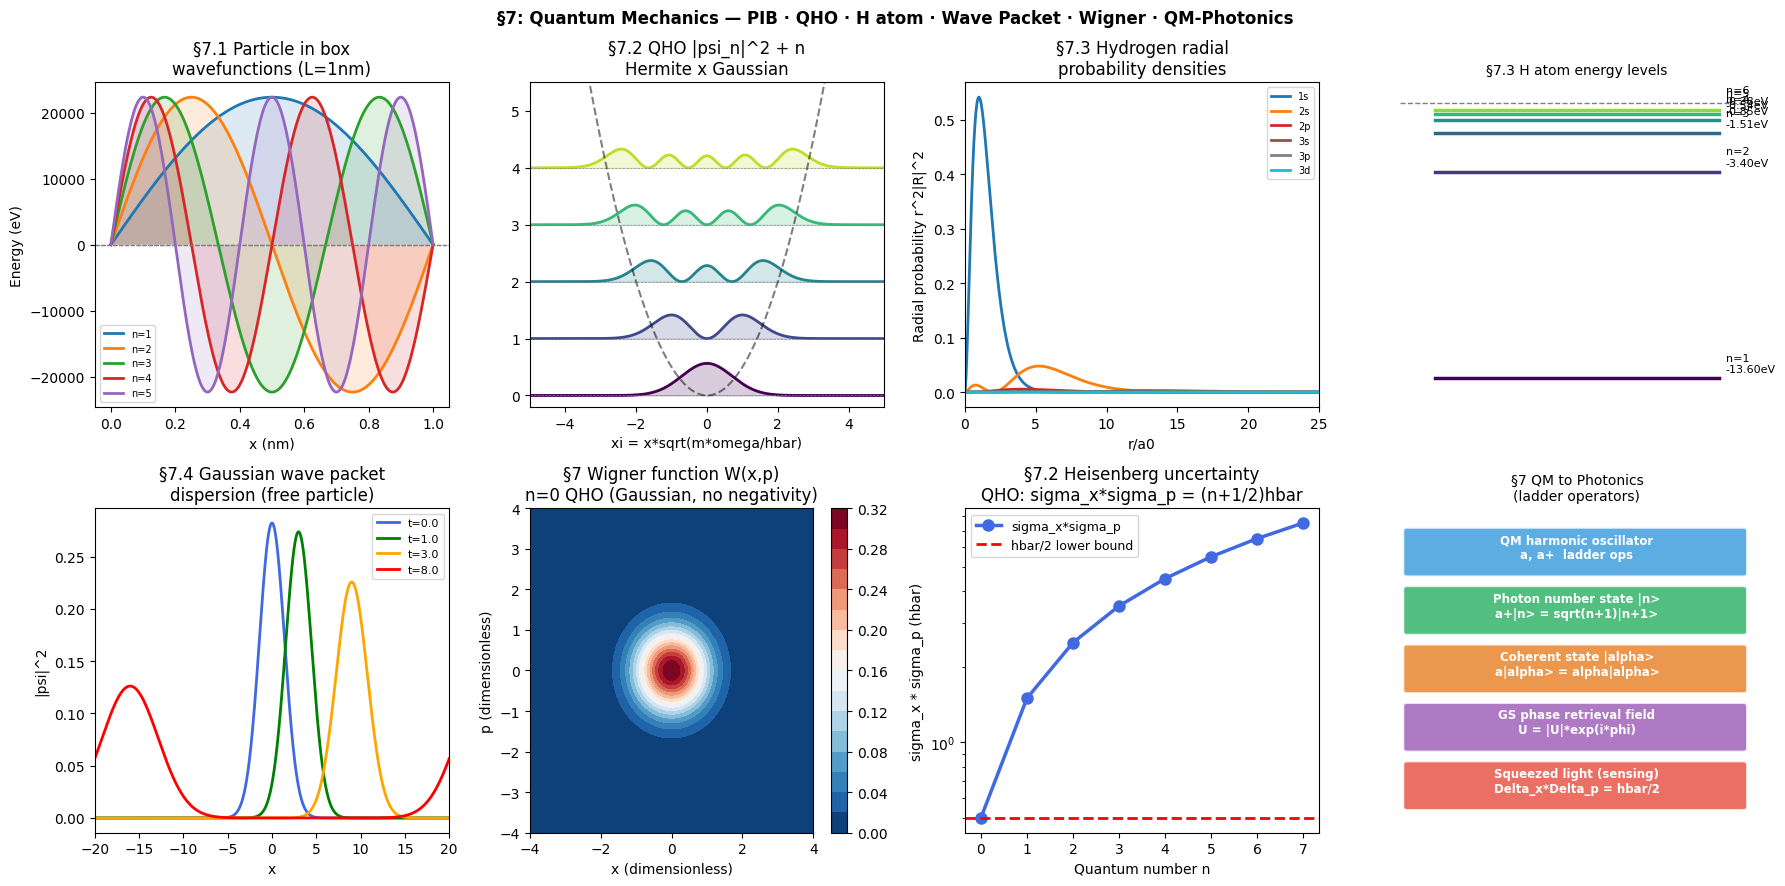

In [9]:
# §7 Quantum mechanics

hbar = 1.0545718e-34   # J*s
m_e  = 9.1094e-31      # kg
eV   = 1.6022e-19      # J
a0   = 5.2918e-11      # Bohr radius m

# §7.1 Particle in a box
print('§7.1 Particle in a box:')
L_box = 1e-9   # 1 nm quantum dot (InGaAs-like)
E1 = np.pi**2 * hbar**2 / (2*m_e*L_box**2) / eV

x_box = np.linspace(0, L_box, 500)
psi_box = {}
E_box   = {}
for n in range(1,7):
    psi_box[n] = np.sqrt(2/L_box)*np.sin(n*np.pi*x_box/L_box)
    E_box[n]   = n**2 * E1
    print(f'  n={n}: E_{n}={E_box[n]:.4f} eV  ({n}^2 * E1)')

# §7.2 Quantum harmonic oscillator (dimensionless units hbar=m=omega=1)
print('\n§7.2 Quantum harmonic oscillator:')
xi_arr = np.linspace(-5, 5, 1000)
psi_ho = {}
from scipy.special import hermite

for n in range(6):
    Hn     = hermite(n)
    norm   = 1/(np.sqrt(2**n * float(sp.factorial(n))) * np.pi**0.25)
    psi_ho[n] = norm * Hn(xi_arr) * np.exp(-xi_arr**2/2)
    E_n    = n + 0.5
    print(f'  n={n}: E = {E_n} hbar*omega  norm={np.trapz(psi_ho[n]**2,xi_arr):.6f}')

# Uncertainty principle check
for n in [0,1,2]:
    psi = psi_ho[n]
    x_exp = np.trapz(xi_arr * psi**2, xi_arr)
    x2_exp= np.trapz(xi_arr**2 * psi**2, xi_arr)
    dx_xi = np.xi_arr[1]-xi_arr[0] if hasattr(np,'xi_arr') else xi_arr[1]-xi_arr[0]
    # momentum via finite diff in position space
    dpsi  = np.gradient(psi, xi_arr)
    p_exp = np.trapz(-1j*psi*dpsi, xi_arr).real
    p2_exp= np.trapz(-psi * np.gradient(dpsi,xi_arr), xi_arr).real
    sig_x = np.sqrt(x2_exp - x_exp**2)
    sig_p = np.sqrt(abs(p2_exp - p_exp**2))
    print(f'  n={n}: sigma_x={sig_x:.4f}  sigma_p={sig_p:.4f}  '
          f'sigma_x*sigma_p={sig_x*sig_p:.4f} (>= 0.5)')

# §7.3 Hydrogen atom radial wavefunctions
print('\n§7.3 Hydrogen atom energy levels:')
r_H = np.linspace(0, 25*a0, 2000)
r_a0= r_H/a0   # in Bohr radii

from scipy.special import genlaguerre, factorial

def hydrogen_radial(n, l, r_bohr):
    rho  = 2*r_bohr/n
    norm = np.sqrt((2/n)**3 * factorial(n-l-1)/(2*n*factorial(n+l)**3))
    L    = genlaguerre(n-l-1, 2*l+1)(rho)
    return norm * np.exp(-rho/2) * rho**l * L

for n in range(1,5):
    E_n = -13.6/n**2
    print(f'  n={n}: E={E_n:.4f} eV  (degeneracy={n**2})')

# Radial probability density |r*R(r)|^2
psi_H = {}
states = [(1,0,'1s'),(2,0,'2s'),(2,1,'2p'),(3,0,'3s'),(3,1,'3p'),(3,2,'3d')]
for n,l,name in states:
    R_nl = hydrogen_radial(n, l, r_a0)
    P_nl = r_a0**2 * R_nl**2   # radial probability density
    r_max= r_a0[np.argmax(P_nl)]
    psi_H[name] = (R_nl, P_nl)

# §7.4 Time evolution of Gaussian wave packet
print('\n§7.4 Gaussian wave packet spreading:')
x_wp  = np.linspace(-20, 20, 4096)
dx_wp = x_wp[1]-x_wp[0]
k0    = 3.0; sigma0 = 2.0
psi0  = np.exp(1j*k0*x_wp) * np.exp(-x_wp**2/(2*sigma0**2))
psi0 /= np.sqrt(np.trapz(np.abs(psi0)**2, x_wp))

k_arr = np.fft.fftfreq(len(x_wp), dx_wp)*2*np.pi
phi_k = np.fft.fft(psi0)   # momentum space

wp_snaps = {0.0: np.abs(psi0)**2}
for t_wp in [1.0, 3.0, 8.0]:
    # Free particle propagator: psi(k,t) = psi(k,0) * exp(-i k^2 t / 2)
    psi_k_t = phi_k * np.exp(-1j*k_arr**2*t_wp/2)
    psi_t   = np.fft.ifft(psi_k_t)
    wp_snaps[t_wp] = np.abs(psi_t)**2

# Check spreading: sigma(t) = sigma0 * sqrt(1 + (t/sigma0^2)^2)
for t_wp in [0.0,1.0,3.0,8.0]:
    P   = wp_snaps[t_wp]
    x_m = np.trapz(x_wp*P, x_wp)
    x2  = np.trapz(x_wp**2*P, x_wp)
    sig = np.sqrt(x2-x_m**2)
    sig_theory = sigma0*np.sqrt(1+(t_wp/sigma0**2)**2) if t_wp>0 else sigma0
    print(f'  t={t_wp:.1f}: sigma_x={sig:.3f}  theory={sig_theory:.3f}')

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2,4,figsize=(18,9))

# Particle in box
ax1 = axes[0][0]
offset = 0
for n in range(1,6):
    E_n_val = E_box[n]
    ax1.axhline(E_n_val+offset, color='gray', lw=0.8, ls='--')
    ax1.plot(x_box*1e9, psi_box[n]*0.5+E_n_val+offset, lw=2, label=f'n={n}')
    ax1.fill_between(x_box*1e9, E_n_val+offset, psi_box[n]*0.5+E_n_val+offset,
                     alpha=0.15)
ax1.set_xlabel('x (nm)'); ax1.set_ylabel('Energy (eV)')
ax1.set_title('§7.1 Particle in box\nwavefunctions (L=1nm)')
ax1.legend(fontsize=7)

# QHO wavefunctions
ax2 = axes[0][1]
for n,col in zip(range(5),plt.cm.viridis(np.linspace(0,0.9,5))):
    ax2.plot(xi_arr, psi_ho[n]**2 + n, color=col, lw=2)
    ax2.axhline(n, color='gray', lw=0.5, ls='--')
    ax2.fill_between(xi_arr, n, psi_ho[n]**2+n, alpha=0.2, color=col)
ax2.plot(xi_arr, 0.5*xi_arr**2, 'k--', lw=1.5, alpha=0.5, label='V(x)=x^2/2')
ax2.set_xlim(-5,5); ax2.set_ylim(-0.2,5.5)
ax2.set_xlabel('xi = x*sqrt(m*omega/hbar)')
ax2.set_title('§7.2 QHO |psi_n|^2 + n\nHermite x Gaussian')

# Hydrogen radial probability
ax3 = axes[0][2]
for (n,l,name),col in zip(states,plt.cm.tab10(np.linspace(0,0.9,len(states)))):
    _,P_nl = psi_H[name]
    ax3.plot(r_a0, P_nl, color=col, lw=2, label=name)
ax3.set_xlim(0,25); ax3.set_xlabel('r/a0')
ax3.set_ylabel('Radial probability r^2|R|^2')
ax3.set_title('§7.3 Hydrogen radial\nprobability densities')
ax3.legend(fontsize=7)

# Hydrogen energy levels
ax4 = axes[0][3]
ax4.axis('off')
ax4.set_title('§7.3 H atom energy levels', fontsize=10)
for n in range(1,7):
    E_n = -13.6/n**2
    ax4.axhline(E_n, xmin=0.1, xmax=0.9, color=plt.cm.viridis((n-1)/6), lw=2.5)
    ax4.text(0.92, E_n+0.2, f'n={n}\n{E_n:.2f}eV', fontsize=8, va='bottom')
ax4.set_xlim(0,1); ax4.set_ylim(-15,1)
ax4.set_ylabel('Energy (eV)')
ax4.axhline(0, color='gray', ls='--', lw=1, label='Ionization limit')

# Wave packet spreading
ax5 = axes[1][0]
colors_wp = ['royalblue','green','orange','red']
for (t_val,P),col in zip(wp_snaps.items(),colors_wp):
    ax5.plot(x_wp, P, color=col, lw=2, label=f't={t_val}')
ax5.set_xlim(-20,20); ax5.set_xlabel('x')
ax5.set_ylabel('|psi|^2')
ax5.set_title('§7.4 Gaussian wave packet\ndispersion (free particle)')
ax5.legend(fontsize=8)

# Wigner function for ground state QHO
ax6 = axes[1][1]
xi_W = np.linspace(-4,4,100)
p_W  = np.linspace(-4,4,100)
XI,PI= np.meshgrid(xi_W,p_W)
# Wigner function for n=0: W(x,p) = (1/pi)*exp(-(x^2+p^2))
W0   = (1/np.pi)*np.exp(-(XI**2+PI**2))
# n=1: W1 = (1/pi)*(2x^2+2p^2-1)*exp(-(x^2+p^2))
W1   = (1/np.pi)*(2*XI**2+2*PI**2-1)*np.exp(-(XI**2+PI**2))
cs6  = ax6.contourf(xi_W,p_W,W0,levels=20,cmap='RdBu_r')
plt.colorbar(cs6,ax=ax6)
ax6.set_xlabel('x (dimensionless)'); ax6.set_ylabel('p (dimensionless)')
ax6.set_title('§7 Wigner function W(x,p)\nn=0 QHO (Gaussian, no negativity)')

# Heisenberg uncertainty principle visualization
ax7 = axes[1][2]
n_vals_heis = np.arange(0,8)
sigma_x_vals = np.sqrt(n_vals_heis + 0.5)   # in dimensionless units
sigma_p_vals = np.sqrt(n_vals_heis + 0.5)
prod_vals    = sigma_x_vals*sigma_p_vals
ax7.semilogy(n_vals_heis, prod_vals, 'o-', color='royalblue', lw=2.5, ms=8, label='sigma_x*sigma_p')
ax7.axhline(0.5, color='red', ls='--', lw=2, label='hbar/2 lower bound')
ax7.set_xlabel('Quantum number n')
ax7.set_ylabel('sigma_x * sigma_p (hbar)')
ax7.set_title('§7.2 Heisenberg uncertainty\nQHO: sigma_x*sigma_p = (n+1/2)hbar')
ax7.legend(fontsize=9)

# QM -> photonics connection diagram
ax8 = axes[1][3]
ax8.axis('off')
ax8.set_title('§7 QM to Photonics\n(ladder operators)', fontsize=10)
items = [
    ('QM harmonic oscillator', 'a, a+  ladder ops', '#3498db'),
    ('Photon number state |n>', 'a+|n> = sqrt(n+1)|n+1>', '#27ae60'),
    ('Coherent state |alpha>', 'a|alpha> = alpha|alpha>', '#e67e22'),
    ('GS phase retrieval field', 'U = |U|*exp(i*phi)', '#9b59b6'),
    ('Squeezed light (sensing)', 'Delta_x*Delta_p = hbar/2', '#e74c3c'),
]
for i,(name,eq,col) in enumerate(items):
    y_i = 0.88 - i*0.18
    ax8.add_patch(mpatches.FancyBboxPatch((0.02,y_i-0.08),0.95,0.13,
                                           boxstyle='round,pad=0.01',
                                           facecolor=col,edgecolor='white',lw=1.5,alpha=0.8))
    ax8.text(0.50,y_i,f'{name}\n{eq}',ha='center',va='center',
             fontsize=8.5,color='white',fontweight='bold')

plt.suptitle('§7: Quantum Mechanics — PIB · QHO · H atom · Wave Packet · Wigner · QM-Photonics',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()